# E-Commerce Shipping Data: 배송 지연 예측 및 분석

**프로젝트 개요:**
본 프로젝트는 전자상거래 배송 데이터를 분석하여 **제품의 배송 지연 여부(Reached.on.Time_Y.N)** 를 예측하는 머신러닝 모델을 구축합니다. 
단순한 예측을 넘어, EDA를 통해 지연의 핵심 원인을 파악하고 파생변수를 생성하여 모델 성능을 최적화하는 과정을 담고 있습니다.

###  github 주소
[github.com/lamph0880/](https://github.com/lamph0880/E-commerce)

# 데이터 불러오기


In [4]:
# 기본 라이브러리
import os, glob, logging
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
if platform.system() == 'Darwin': 
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': 
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 관련
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, 
    StratifiedKFold, cross_validate, cross_val_predict)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder

# 모델링
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, StackingClassifier)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


from autogluon.tabular import TabularPredictor

# 성능 평가
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, precision_recall_fscore_support)

In [5]:
!kaggle datasets download prachi13/customer-analytics -p ./data

Dataset URL: https://www.kaggle.com/datasets/prachi13/customer-analytics
License(s): other
customer-analytics.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
HOME = os.getcwd()

zipPath = os.path.join(HOME, 'data','customer-analytics.zip')

targetPath = os.path.join(HOME, 'data')

In [7]:
from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)

In [8]:
trainPath = os.path.join(targetPath, 'Train.csv')
df = pd.read_csv(trainPath)

In [9]:
TARGET = 'Reached.on.Time_Y.N'
target = 'Reached.on.Time_Y.N'

# 데이터 분석 과정 (EDA)

1) 특성 상관관계 시각화
2) 파생변수 생성
3) 인코딩 과정
4) 스케일링 과정

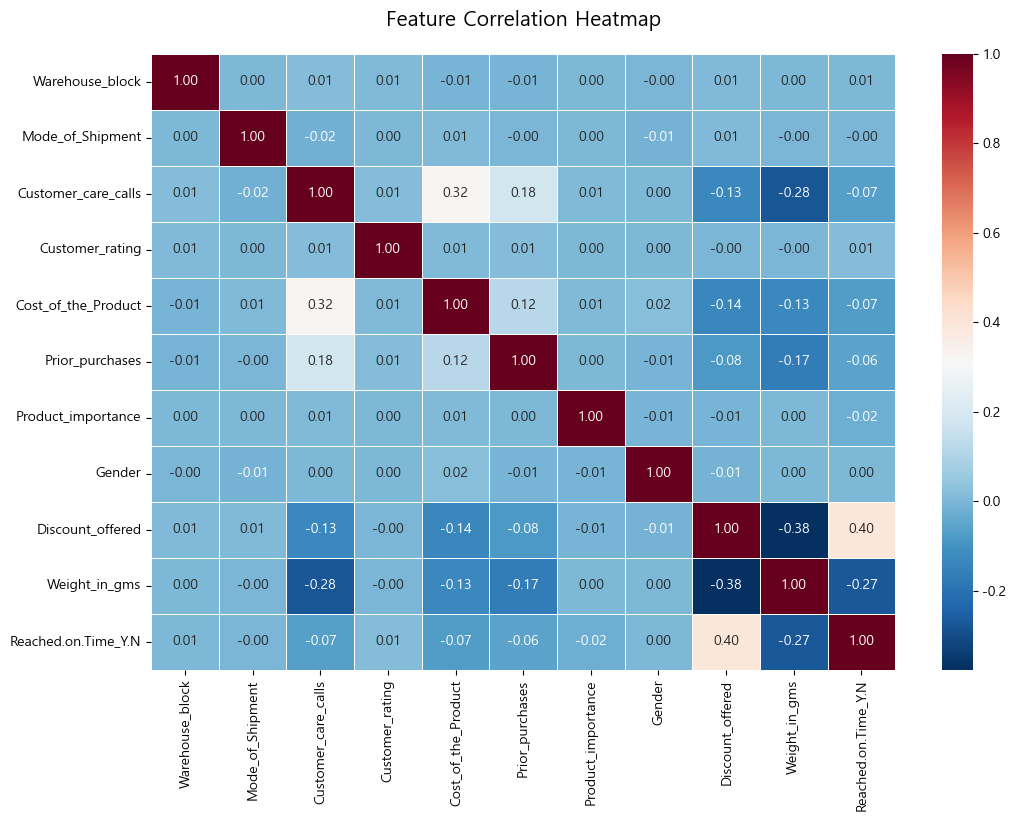

In [10]:
data = df.copy().drop(columns=['ID'])

# 라벨 인코딩
le = LabelEncoder()
object_cols = data.select_dtypes(include=['object']).columns

for col in object_cols:
    data[col] = le.fit_transform(data[col])

# 히트맵 시각화
plt.figure(figsize=(12, 8)) 
sns.heatmap(data.corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', 
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=15, pad=20)
plt.show()

In [11]:
# 데이터 분리
part1, part2 = train_test_split(df, 
                                test_size=0.2, 
                                random_state=42, 
                                stratify=df['Reached.on.Time_Y.N'])

# 각각 파일로 저장
part1.to_csv('data/train_df.csv', index=False)
part2.to_csv('data/test_df.csv', index=False)

print(f"학습용: {part1.shape}, 테스트용: {part2.shape}")

학습용: (8799, 12), 테스트용: (2200, 12)


In [12]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')

In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   8799 non-null   int64 
 1   Warehouse_block      8799 non-null   object
 2   Mode_of_Shipment     8799 non-null   object
 3   Customer_care_calls  8799 non-null   int64 
 4   Customer_rating      8799 non-null   int64 
 5   Cost_of_the_Product  8799 non-null   int64 
 6   Prior_purchases      8799 non-null   int64 
 7   Product_importance   8799 non-null   object
 8   Gender               8799 non-null   object
 9   Discount_offered     8799 non-null   int64 
 10  Weight_in_gms        8799 non-null   int64 
 11  Reached.on.Time_Y.N  8799 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 825.0+ KB


In [11]:
def split_feature_types(df, threshold=10):
    temp_df = df.copy()
    if 'ID' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ID'])
        
    # 타겟 제외
    target_name = 'Reached.on.Time_Y.N'
    features = [col for col in temp_df.columns if col != target_name]
    
    cat_cols = []
    num_cols = []
    
    for col in features:
        # 데이터 타입이 object/category거나, 고유값 개수가 적은 경우 범주형으로 분류
        if temp_df[col].dtype in ['object', 'category'] or temp_df[col].nunique() <= threshold:
            cat_cols.append(col)
        # 그 외에는 수치형으로 분류
        else:
            num_cols.append(col)

    print(f'범주형:{cat_cols}')
    print(f'숫자형:{num_cols}')
    return cat_cols, num_cols

In [12]:
cat_cols, num_cols = split_feature_types(train_df)

범주형:['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
숫자형:['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


In [13]:
importance_order = ['low', 'medium', 'high']
train_df['Product_importance'] = pd.Categorical(train_df['Product_importance'], 
                                         categories=importance_order, 
                                         ordered=True)

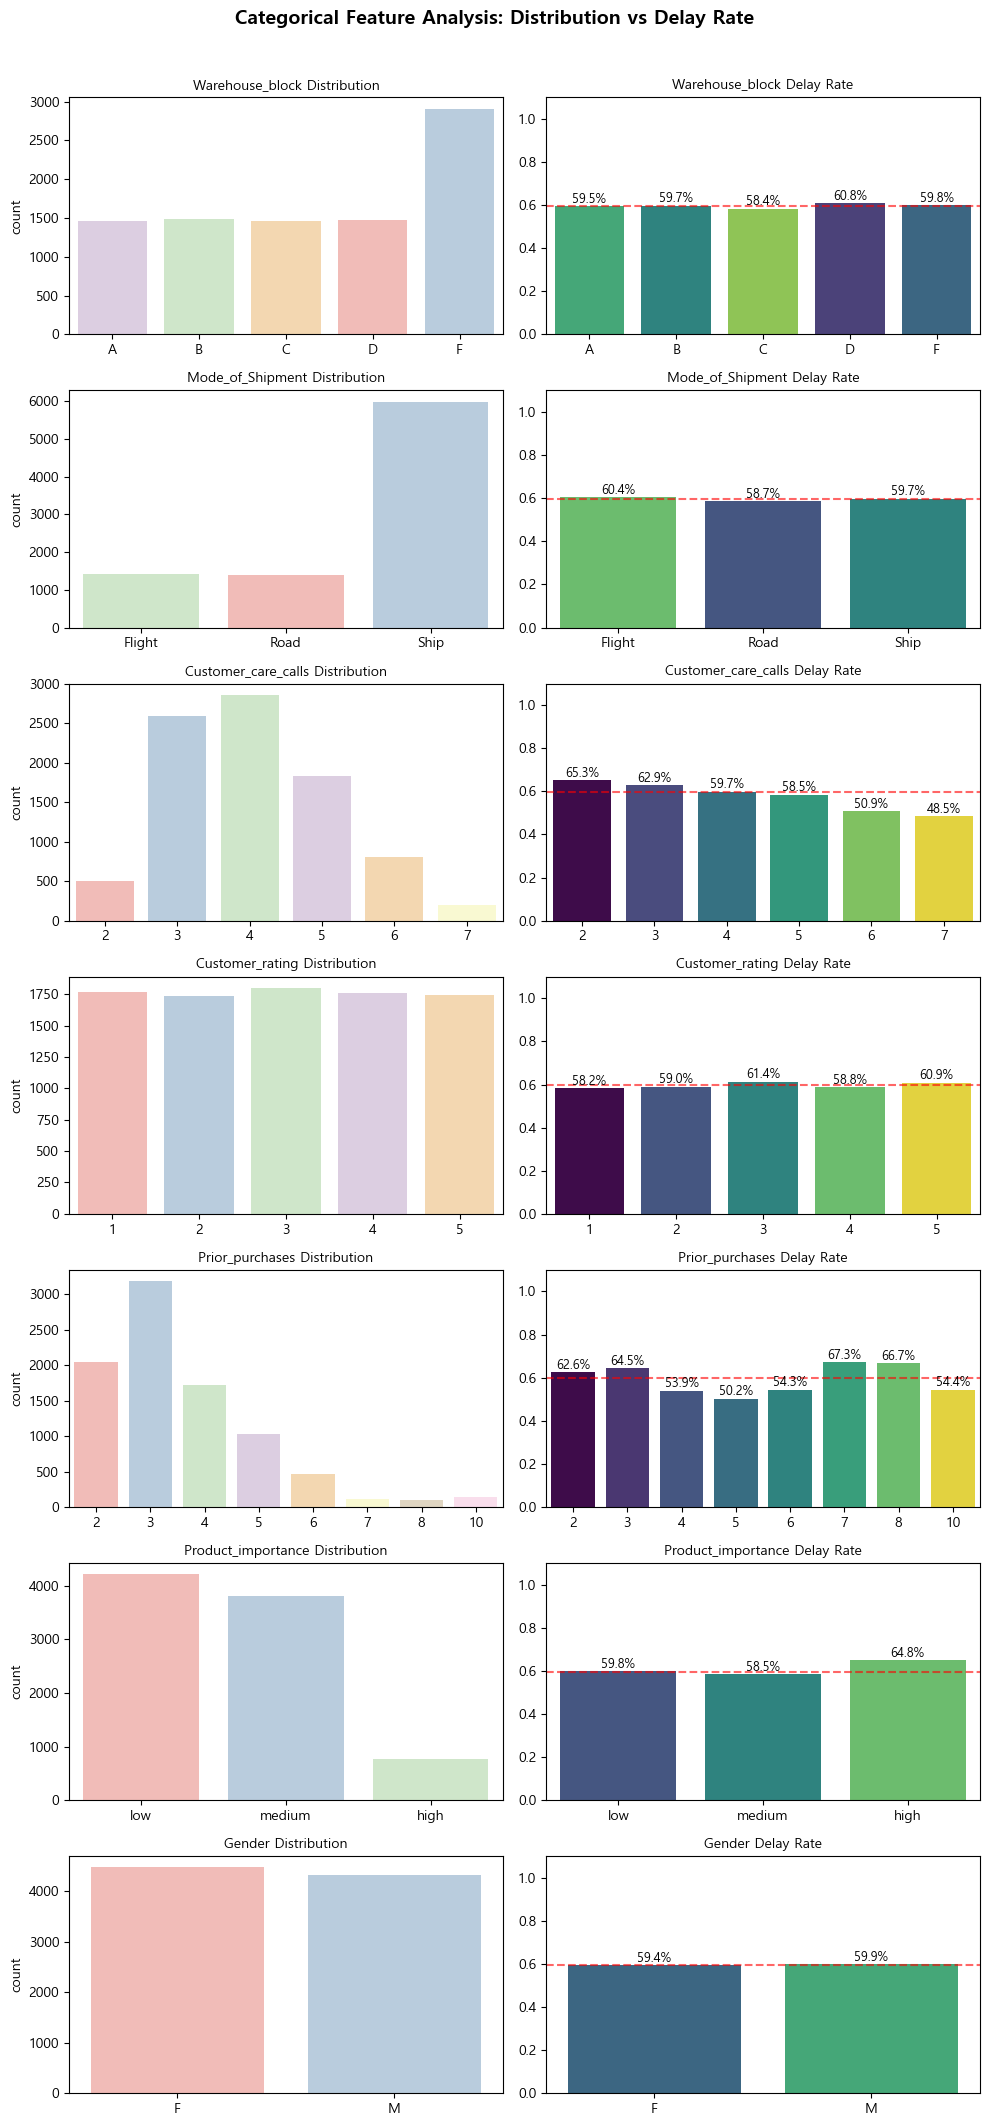

In [14]:
# 범주형 특성

target = 'Reached.on.Time_Y.N'

def plot_categorical_analysis(df, features, target):
    num_features = len(features)
    rows = num_features 
    
    plt.figure(figsize=(10, rows * 3))
    plt.suptitle('Categorical Feature Analysis: Distribution vs Delay Rate', fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(features):
        
        if df[col].dtype.name == 'category':
            order = df[col].cat.categories.tolist()
        else:
            order = sorted(df[col].unique())
        
        # 빈도 분포
        plt.subplot(rows, 2, i * 2 + 1)
        sns.countplot(x=col, data=df, order=order, palette='Pastel1', hue=col, legend=False)
        plt.title(f'{col} Distribution', fontsize=10)
        plt.xlabel('')
       
        # 지연율
        plt.subplot(rows, 2, i * 2 + 2)
        ax = sns.barplot(
            x=col, y=target, data=df, order=order, 
            palette='viridis', hue=col, legend=False, errorbar=None
        )
        
        # 전체 평균 지연율 기준선
        avg_rate = df[target].mean()
        ax.axhline(avg_rate, color='red', linestyle='--', alpha=0.6)
        
        # 수치 표시
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.1%}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

        plt.title(f'{col} Delay Rate', fontsize=10)
        plt.xlabel('')
        plt.ylabel('')
        plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

plot_categorical_analysis(train_df, cat_cols, target)

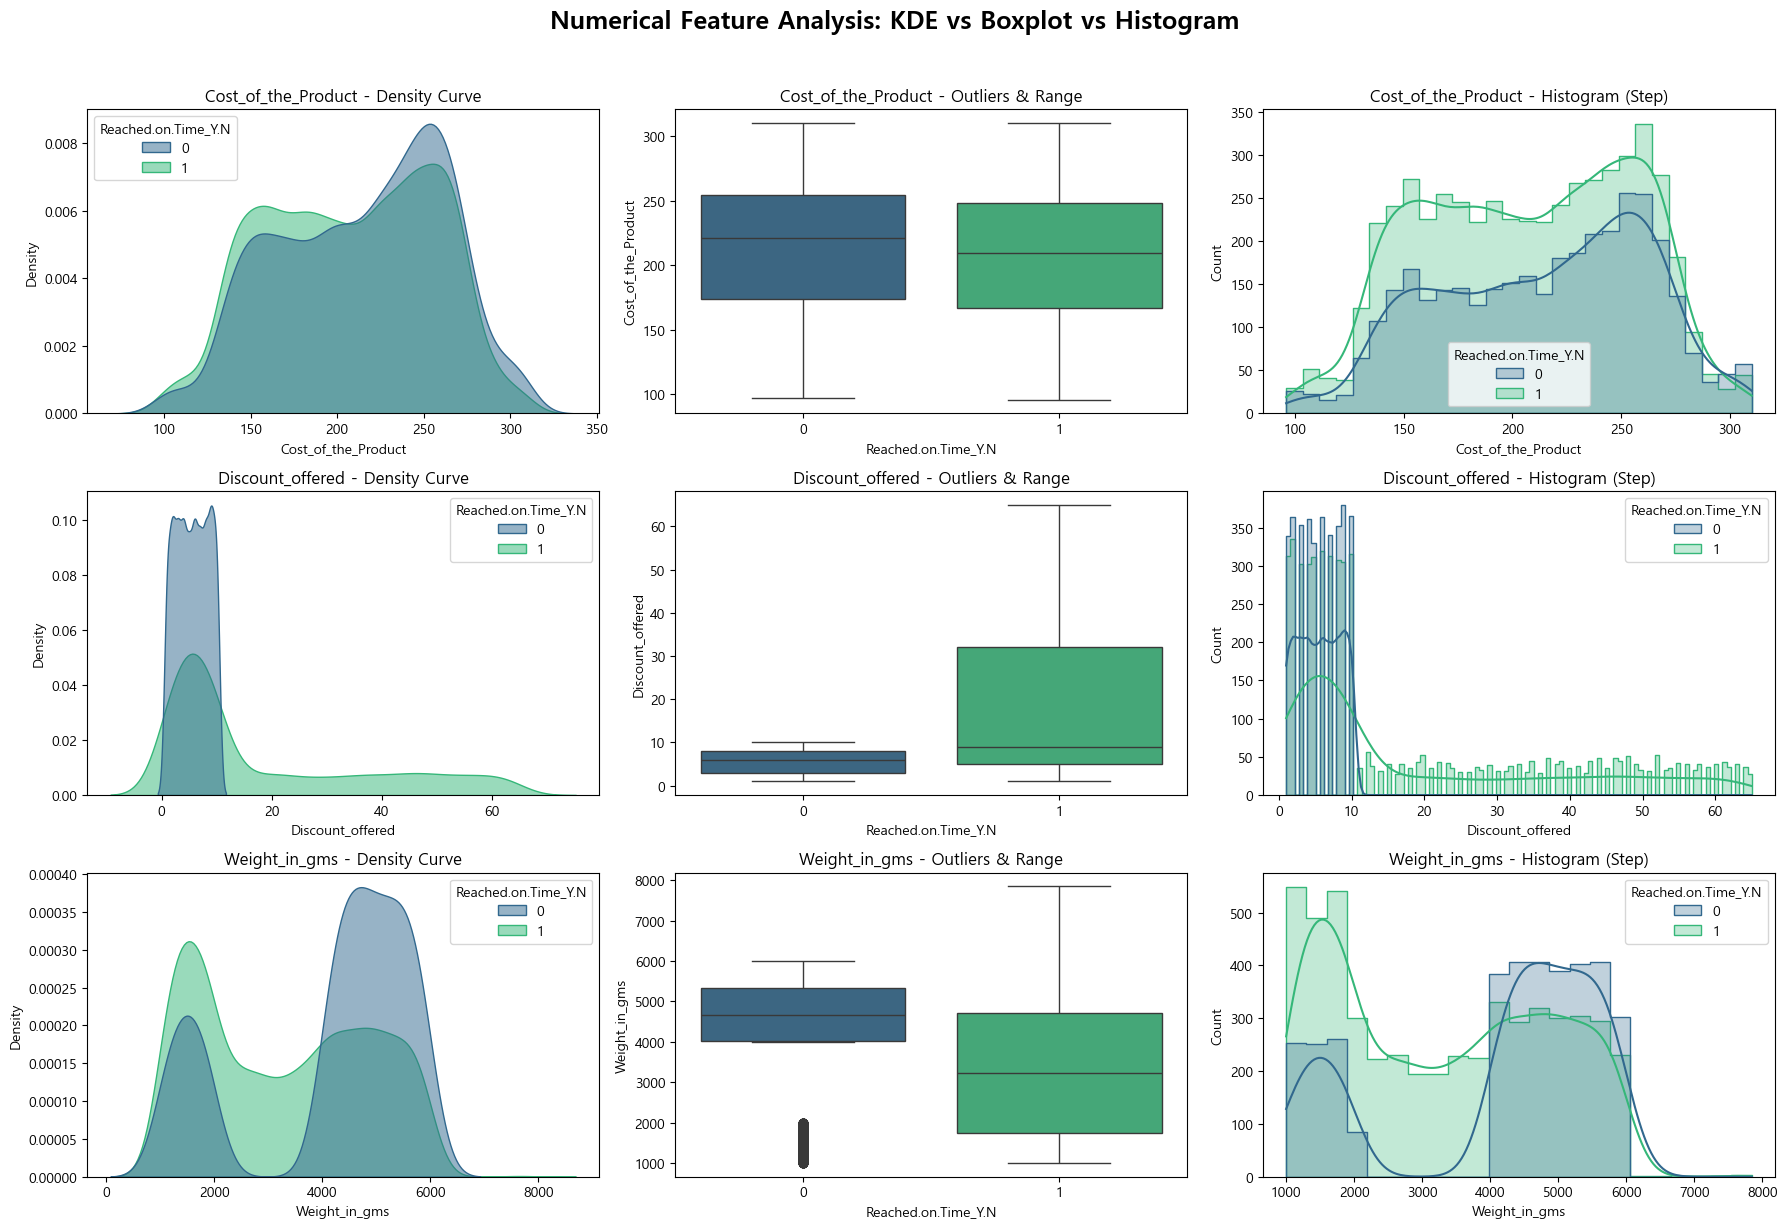

In [15]:
# 수치형 특성

def plot_numeric_analysis(df, features, target):
    num_features = len(features)
    plt.figure(figsize=(18, num_features * 4))
    plt.suptitle('Numerical Feature Analysis: KDE vs Boxplot vs Histogram', fontsize=18, fontweight='bold', y=1.02)

    for i, col in enumerate(features):
        # KDE Plot: 두 그룹의 밀도 곡선 비교
        plt.subplot(num_features, 3, i*3 + 1)
        sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, palette='viridis', alpha=0.5)
        plt.title(f'{col} - Density Curve', fontsize=12)

        # Boxplot: 중앙값 및 이상치 확인
        plt.subplot(num_features, 3, i*3 + 2)
        sns.boxplot(data=df, x=target, y=col, hue=target, palette='viridis', legend=False)
        plt.title(f'{col} - Outliers & Range', fontsize=12)
        
        # Histogram + KDE: 실제 데이터 빈도와 곡선 결합
        plt.subplot(num_features, 3, i*3 + 3)
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", palette='viridis', alpha=0.3)
        plt.title(f'{col} - Histogram (Step)', fontsize=12)

    plt.tight_layout()
    plt.show()

plot_numeric_analysis(train_df, num_cols, target)

In [16]:
copy_df = train_df.copy()

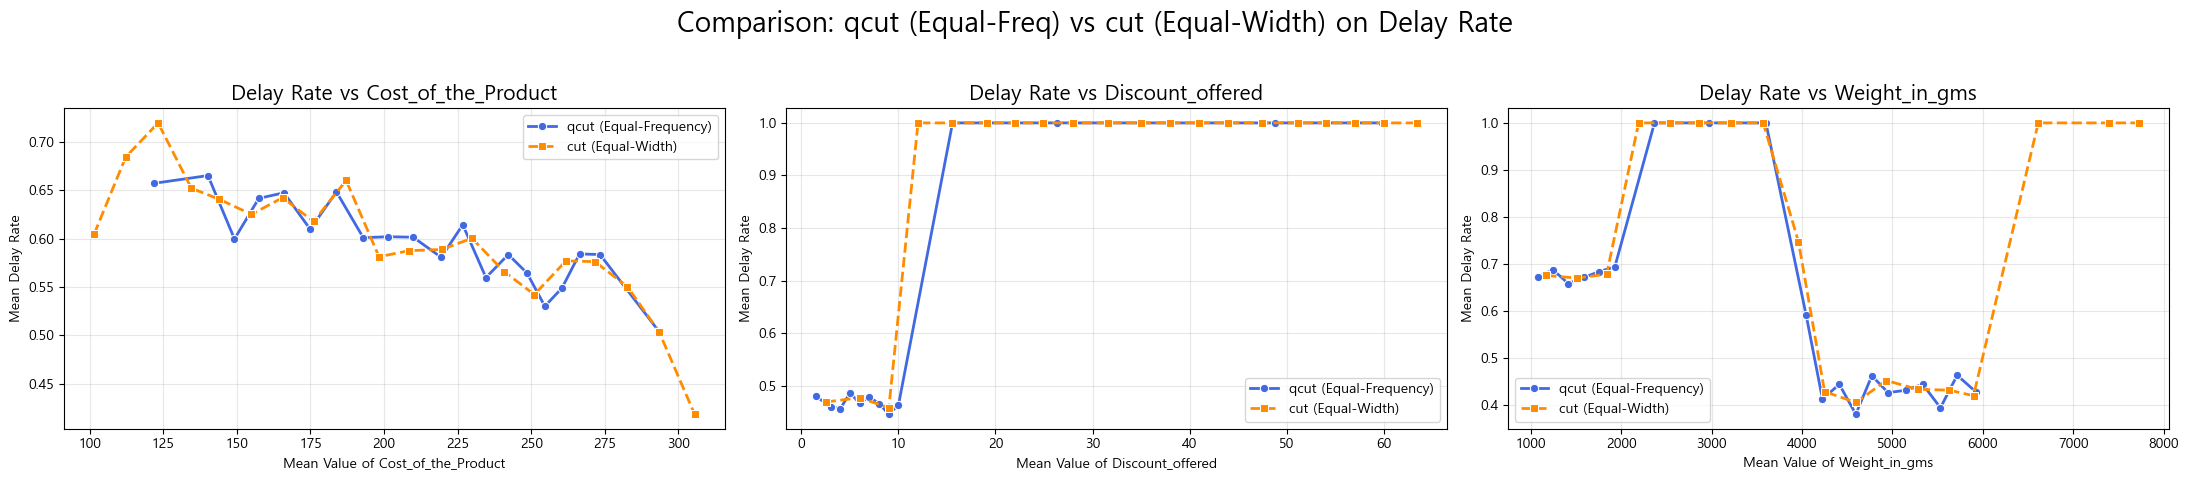

In [17]:
# 수치형 변수
features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

# 서브플롯 설정
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Comparison: qcut (Equal-Freq) vs cut (Equal-Width) on Delay Rate', fontsize=20)

for i, col in enumerate(features):
    temp_df = copy_df.copy()
    
    # qcut (데이터 개수 균등) 계산
    temp_df['qcut_Bin'] = pd.qcut(temp_df[col], q=20, duplicates='drop')
    qcut_stats = temp_df.groupby('qcut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # cut (수치 거리 균등) 계산
    temp_df['cut_Bin'] = pd.cut(temp_df[col], bins=20)
    cut_stats = temp_df.groupby('cut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # 시각화
    # qcut 라인 (파란색)
    sns.lineplot(x=qcut_stats[col], y=qcut_stats[target], marker='o', 
                 ax=axes[i], label='qcut (Equal-Frequency)', color='royalblue', linewidth=2)
    
    # cut 라인 (주황색)
    sns.lineplot(x=cut_stats[col], y=cut_stats[target], marker='s', 
                 ax=axes[i], label='cut (Equal-Width)', color='darkorange', linewidth=2, linestyle='--')
    
    axes[i].set_title(f'Delay Rate vs {col}', fontsize=15)
    axes[i].set_xlabel(f'Mean Value of {col}')
    axes[i].set_ylabel('Mean Delay Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [18]:
def apply_feature_engineering(df):
    # 할인율 10% 초과 여부
    df['Discount_Group'] = (df['Discount_offered'] > 10).astype(int)
    
    # 무게 별 구간
    conditions = [
    (df['Weight_in_gms'] >= 4000) & (df['Weight_in_gms'] < 6000), 
    (df['Weight_in_gms'] >= 0) & (df['Weight_in_gms'] < 2000)     
    ]

    # 해당 조건에 대응하는 값 리스트
    choices = [0, 1]
    # 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
    df['Weight_Category'] = np.select(conditions, choices, default=2)
   

    # 창고별 배송수단 조합 
    df['Wh_Shipment_Combo'] = df['Warehouse_block'].astype(str) + '_' + df['Mode_of_Shipment'].astype(str)
    
    # 모델 학습을 위해 범주형을 숫자로 매핑
    le = LabelEncoder()
    df['Wh_Shipment_Combo'] = le.fit_transform(df['Wh_Shipment_Combo']) + 1


    # 이상치 처리
    df['Prior_purchases'] = df['Prior_purchases'].clip(upper=6)
    df['Customer_care_calls'] = df['Customer_care_calls'].clip(lower=3, upper=6)


    # 할인 적용 가격
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # 무게 대비 가격, 로그 변환
    df['Price_per_weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] / 1000)
    df['log_price_per_weight'] = np.log(df['Price_per_weight'])
    df['log_price_per_weight_sq'] =df['log_price_per_weight'] ** 2


    # 할인율
    df['Discount_rate'] = (df['Discount_offered'] / df['Cost_of_the_Product'])*100

    # 화물관리점수 (값은 싼데, 무겁고, 손이 많이 가는 화물, 지연율이 높아질 가능성)
    df['Management_score'] = (df['Customer_care_calls'] / df['Price_per_weight']) * ((df['Weight_in_gms']/1000)**1.5)
    df['Management_score_sq'] = df['Management_score'] ** 2

    return df

# 각각의 데이터셋에 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)

In [19]:
drop_columns = ["ID", "Gender", "Customer_rating"]
train_df = train_df.drop(drop_columns, axis=1)
test_df = test_df.drop(drop_columns, axis=1)

In [20]:
def apply_feature_preprocessing(df):

    # Label Encoding
    importance_map = {'low': 0, 'medium': 1, 'high': 2}
    df['Product_importance'] = df['Product_importance'].map(importance_map)

    # One-Hot Encoding
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment'])

    return df
    
# 각각의 데이터셋에 적용
train_df = apply_feature_preprocessing(train_df)
test_df = apply_feature_preprocessing(test_df)

In [21]:
# Scaling 컬럼
num_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
                    'Discount_rate', 'Management_score', 'log_price_per_weight_sq', 'Management_score_sq']

scaler = StandardScaler()

train_df[num_features] = scaler.fit_transform(train_df[num_features])

test_df[num_features] = scaler.transform(test_df[num_features])

# 모델링 및 하이퍼파라미터 과정
1) 베이스라인 모델 생성
2) 파생변수 적용 모델 비교
3) 튜닝 모델 비교
4) Autogluon 모델 비교

In [22]:
seed = 42
SEED = 42
TARGET = 'Reached.on.Time_Y.N'
K = 5           # 5-Fold CV
GAP_LIMIT = 0.10 # 과적합 판정 기준
CV_NJOBS = -1   # 병렬 처리

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
scoring = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

In [23]:
train_raw = pd.read_csv('data/train_df.csv') 
test_raw  = pd.read_csv('data/test_df.csv')

# FE용 복사본 생성
train_fe = train_raw.copy()
test_fe  = test_raw.copy()

In [24]:
# 전처리 함수
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    
    pre = ColumnTransformer(
        transformers=[
            ("cat", make_ohe(), cat_cols),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop")
    return pre

# 모델 목록
models = [
    ('Logistic', LogisticRegression(max_iter=2000, random_state=SEED)),
    ('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=SEED)),
    ('k-NN', KNeighborsClassifier(n_neighbors=15)),
    ('SVM', SVC(probability=True, random_state=SEED)),
    ('RandomForest', RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=SEED)),
    ('ExtraTrees', ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=SEED)),
    ('GradBoost', GradientBoostingClassifier(random_state=SEED)),
    ('XGBoost', XGBClassifier(n_estimators=800, learning_rate=0.05, max_depth=4, random_state=SEED, eval_metric="logloss", verbosity=0)),
    ('LightGBM', LGBMClassifier(n_estimators=1200, learning_rate=0.03, max_depth=4, random_state=SEED, verbose=-1)),
    ('CatBoost', CatBoostClassifier(depth=4, iterations=1500, learning_rate=0.05, random_state=SEED, verbose=0, allow_writing_files=False))]

In [25]:
if 'model_performance_list' not in locals():
    model_performance_list = []

### 베이스라인 모델생성

In [26]:
base_features = [
    'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 
    'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 
    'Product_importance', 'Discount_offered', 'Weight_in_gms']

X_base = train_raw[base_features]
y_base = train_raw[TARGET]

# 전처리기 생성
pre = make_preprocessor(X_base)

baseline_rows = []
for name, model in models:
    # 파이프라인 결합
    pipe = Pipeline([('preprocessor', pre), ('classifier', model)])
    
    cvres = cross_validate(
        pipe, X_base, y_base,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=CV_NJOBS)

    val_auc = np.mean(cvres["test_roc_auc"])
    train_auc = np.mean(cvres["train_roc_auc"])
    
    baseline_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": train_auc - val_auc,
        "Overfit_Flag": (train_auc - val_auc) > GAP_LIMIT})

baseline_report = pd.DataFrame(baseline_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
baseline_report.insert(0, "Rank", np.arange(1, len(baseline_report) + 1))

display(baseline_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6803,0.9322,0.5008,0.6513,0.7442,0.7547,0.0105,False
1,2,GradBoost,0.6768,0.8679,0.5410,0.6662,0.7380,0.8223,0.0843,False
2,3,CatBoost,0.6568,0.7536,0.6312,0.6870,0.7346,0.9395,0.2049,True
3,4,RandomForest,0.6556,0.7622,0.6158,0.6810,0.7340,0.9999,0.2659,True
4,5,ExtraTrees,0.6573,0.7399,0.6571,0.6959,0.7318,0.9996,0.2678,True
5,6,XGBoost,0.6573,0.7568,0.6278,0.6861,0.7311,0.9291,0.1980,True
6,7,k-NN,0.6534,0.7433,0.6402,0.6878,0.7309,0.8122,0.0813,False
7,8,LightGBM,0.6530,0.7512,0.6259,0.6828,0.7296,0.9181,0.1885,True
8,9,SVM,0.6579,0.7233,0.6910,0.7068,0.7223,0.7226,0.0003,False
9,10,Logistic,0.6404,0.7065,0.6802,0.6930,0.7202,0.7240,0.0038,False


### 파생변수 모델 생성과정

In [27]:
train_fe = apply_feature_engineering(train_fe)
test_fe  = apply_feature_engineering(test_fe)

In [28]:
optimal_8_features = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq']

X_case_b_95 = train_fe[optimal_8_features]
y_case_b_95 = train_fe[TARGET]  # y값도 데이터프레임 안의 정답 컬럼으로 지정

# 필수 체크
assert 'train_fe' in globals() and 'test_fe' in globals(), "train_fe/test_fe가 없습니다. FE 적용 셀 아래에 넣어주세요."
assert 'TARGET' in globals(), "TARGET 변수가 없습니다. TARGET='Reached.on.Time_Y.N' 셀 아래/근처에 넣어주세요."
assert 'optimal_8_features' in globals(), "optimal_8_features가 없습니다. 8개 변수 리스트 정의 후에 넣어주세요."

base_drop_cols = [TARGET, 'ID', 'Gender']
drop_cols = [c for c in base_drop_cols if c in train_fe.columns]

# 인덱스 정렬 이슈 차단
X_train_fe = train_fe.drop(columns=drop_cols).reset_index(drop=True)
y_train    = train_fe[TARGET].astype(int).reset_index(drop=True)

X_test_fe  = test_fe.drop(columns=drop_cols).reset_index(drop=True)
y_test     = test_fe[TARGET].astype(int).reset_index(drop=True)

# 8개 변수 버전도 함께 고정
missing = [c for c in optimal_8_features if c not in X_train_fe.columns]
assert len(missing) == 0, f"optimal_8_features 중 train_fe에 없는 컬럼이 있습니다: {missing}"

X_train_8 = X_train_fe[optimal_8_features].copy()
X_test_8  = X_test_fe[optimal_8_features].copy()

In [29]:
drop_cols = ['ID', 'Gender', TARGET] # 제거할 컬럼 리스트
X_fe_all = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns])
y_fe_all = train_fe[TARGET]

fe_all_rows = []

# 전처리기 생성
pre_fe = make_preprocessor(X_fe_all)

for name, model in models:
    # 파이프라인 결합
    pipe = Pipeline([('preprocessor', pre_fe), ('classifier', model)])
    
    cvres = cross_validate(
        pipe, X_fe_all, y_fe_all,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1) 

    # 지표 계산
    val_auc = np.mean(cvres["test_roc_auc"])
    train_auc = np.mean(cvres["train_roc_auc"])
    
    fe_all_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": train_auc - val_auc,
        "Overfit_Flag": (train_auc - val_auc) > 0.05 })# GAP_LIMIT 대신 0.05나 변수 사용

# 결과 리포트 출력
fe_all_report = pd.DataFrame(fe_all_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
fe_all_report.insert(0, "Rank", np.arange(1, len(fe_all_report) + 1))

display(fe_all_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'}))

,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,False
1,2,GradBoost,0.6775,0.8649,0.5451,0.6683,0.7425,0.8376,0.0951,True
2,3,XGBoost,0.6589,0.7575,0.6303,0.6880,0.7383,0.9576,0.2193,True
3,4,CatBoost,0.6561,0.7492,0.6368,0.6884,0.7377,0.9656,0.2279,True
4,5,RandomForest,0.6543,0.7565,0.6208,0.6818,0.7363,1.0000,0.2637,True
5,6,LightGBM,0.6571,0.7539,0.6318,0.6874,0.7357,0.9471,0.2114,True
6,7,Logistic,0.6691,0.8063,0.5867,0.6790,0.7354,0.7407,0.0053,False
7,8,k-NN,0.6594,0.7491,0.6455,0.6934,0.7354,0.8150,0.0796,True
8,9,ExtraTrees,0.6526,0.7559,0.6173,0.6794,0.7321,1.0000,0.2679,True
9,10,SVM,0.6589,0.7273,0.6853,0.7057,0.7289,0.7293,0.0004,False


### 변수중요도 확인

* 변수가 너무 많으면 모델의 성능이 악화될 수 있음
* 중요하다고 생각하는 변수를 추려내기

,Feature,Importance,Percentage (%)
0,Discount_Group,0.4737,47.37%
1,Discount_offered,0.2432,24.32%
2,Weight_Category,0.1009,10.09%
3,Weight_in_gms,0.0315,3.15%
4,Discounted_price,0.0296,2.96%
5,Discount_rate,0.0296,2.96%
6,log_price_per_weight_sq,0.0166,1.66%
7,Price_per_weight,0.0160,1.60%
8,Cost_of_the_Product,0.0147,1.47%
9,log_price_per_weight,0.0120,1.20%


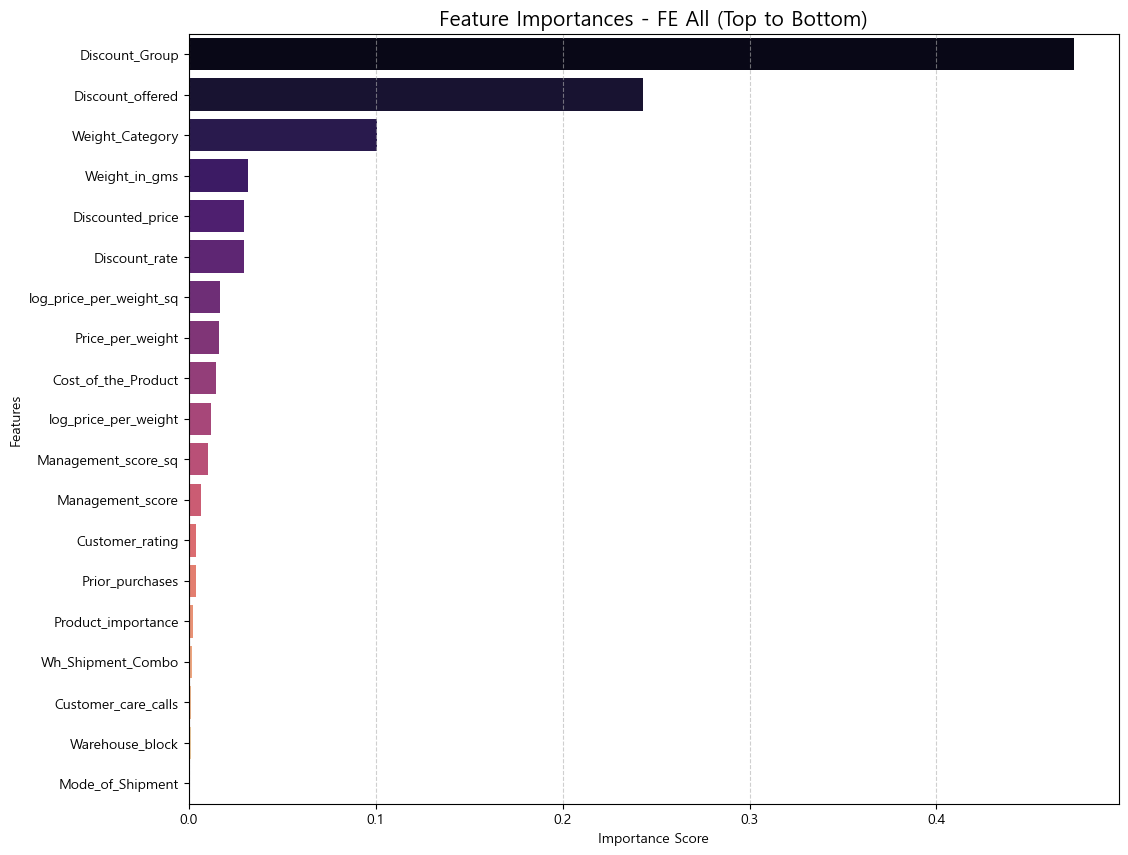

In [30]:
X_fe_encoded = X_fe_all.copy()

cat_cols = X_fe_encoded.select_dtypes(include=['object', 'category']).columns

oe = OrdinalEncoder()
X_fe_encoded[cat_cols] = oe.fit_transform(X_fe_encoded[cat_cols])

all_features_names = X_fe_encoded.columns

model_24 = GradientBoostingClassifier(random_state=42)
model_24.fit(X_fe_encoded, y_fe_all) 

all_importances = model_24.feature_importances_

fi_all_df = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': all_importances})

fi_all_df['Percentage (%)'] = (fi_all_df['Importance'] / fi_all_df['Importance'].sum()) * 100
fi_all_df = fi_all_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

display(fi_all_df.style.format({'Importance': '{:.4f}', 'Percentage (%)': '{:.2f}%'})
                 .background_gradient(cmap='Reds', subset=['Importance']))

plt.figure(figsize=(12, 10))
sns.barplot(data=fi_all_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importances - FE All (Top to Bottom)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [31]:
# 줄인 변수를 채점하기 위한 함수 생성
def get_model_report(X, y, case_name):

    report_rows = []
    preprocessor = make_preprocessor(X)
    
    for name, model in models:
        pipe = Pipeline([('pre', preprocessor), ('clf', model)])
        
        cvres = cross_validate(
            pipe, X, y, cv=skf, n_jobs=-1,
            scoring=scoring, return_train_score=True)

        train_auc = np.mean(cvres["train_roc_auc"])
        val_auc   = np.mean(cvres["test_roc_auc"])
        gap_auc   = train_auc - val_auc

        report_rows.append({
            "Model": name,
            "Accuracy": np.mean(cvres["test_accuracy"]),
            "Precision": np.mean(cvres["test_precision"]),
            "Recall": np.mean(cvres["test_recall"]),
            "F1_Score": np.mean(cvres["test_f1"]),
            "Val_ROC_AUC": val_auc,
            "Train_ROC_AUC": train_auc,
            "AUC_Gap": gap_auc,
            "Overfit_Flag": gap_auc > GAP_LIMIT})

    report_df = pd.DataFrame(report_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
    report_df.insert(0, "Rank", np.arange(1, len(report_df) + 1))
    return report_df

In [32]:
cols_A0 = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
    'Prior_purchases', 'Product_importance', 'Discount_offered', 
    'Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 
    'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
    'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 
    'Management_score_sq']

cols_A = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
    'Prior_purchases', 'Product_importance', 'Discount_offered', 
    'Discount_Group', 'Discounted_price', 'Discount_rate', 
    'Management_score', 'Management_score_sq']

cols_A2 = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Discount_rate', 'Discounted_price']

cols_B = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq']

In [33]:
assert 'train_fe' in globals() and 'test_fe' in globals(), "train_fe/test_fe가 없습니다. FE 적용 셀(143) 먼저 실행하세요."
assert TARGET in train_fe.columns and TARGET in test_fe.columns, f"TARGET({TARGET}) 컬럼이 train_fe/test_fe에 없습니다."

FEATURE_CASE = "B"

FEATURE_MAP = {
    "A0": cols_A0,
    "A":  cols_A,
    "A2": cols_A2,
    "B":  cols_B}
FEATURES = FEATURE_MAP[FEATURE_CASE]

X_train_shared = train_fe[FEATURES].copy()
y_train_shared = train_fe[TARGET].astype(int).copy()

X_test_shared  = test_fe[FEATURES].copy()
y_test_shared  = test_fe[TARGET].astype(int).copy()

In [34]:
report_A0 = get_model_report(X_fe_all[cols_A0], y_fe_all, "A0 (16-Original)")
report_A  = get_model_report(X_fe_all[cols_A],  y_fe_all, "A (11-NoiseFree)")
report_A2 = get_model_report(X_fe_all[cols_A2], y_fe_all, "A2 (5-Best)")
report_B  = get_model_report(X_fe_all[cols_B],  y_fe_all, "B (8-Optimal)")

In [35]:
report_A0_named = report_A0.copy()
report_A0_named.insert(0, 'Test_Case', 'A0 (16-Org)')

report_A_named = report_A.copy()
report_A_named.insert(0, 'Test_Case', 'A (11-Strict)')

report_A2_named = report_A2.copy()
report_A2_named.insert(0, 'Test_Case', 'A2 (5-Best)')

report_B_named = report_B.copy()
report_B_named.insert(0, 'Test_Case', 'B (8-Opt)')

all_comparison = pd.concat([
    report_A0_named, 
    report_A_named, 
    report_A2_named, 
    report_B_named], axis=0).reset_index(drop=True)

all_comparison = all_comparison.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True).head(5)

all_comparison['Rank'] = all_comparison.index + 1

display(all_comparison.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({'Val_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'}))

,Test_Case,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,B (8-Opt),1,GradBoost,0.679623,0.873190,0.541905,0.668551,0.7455,0.827683,0.0822,False
1,B (8-Opt),2,DecisionTree,0.685987,0.969860,0.488952,0.650074,0.7450,0.753751,0.0087,False
2,A2 (5-Best),3,DecisionTree,0.686782,0.982611,0.483619,0.648126,0.7439,0.748805,0.0049,False
3,A0 (16-Org),4,DecisionTree,0.686668,0.978103,0.485905,0.649075,0.7430,0.752063,0.0091,False
4,A0 (16-Org),5,GradBoost,0.676326,0.874226,0.534857,0.663320,0.7421,0.833812,0.0917,False


In [36]:
try:
    if 'report_base' not in locals(): report_base = baseline_report
    if 'report_fe_all' not in locals(): report_fe_all = fe_all_report
    print("clear")
except NameError:
    print("error")

model_performance_list = [] 

full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B)]

for case_name, rpt in full_flow_list:
    best_row = rpt.iloc[0] 
    
    model_performance_list.append({
        'Case': case_name,
        'Model': best_row['Model'],
        'Val_ROC_AUC': best_row['Val_ROC_AUC'],
        'Accuracy': best_row['Accuracy'],
        'AUC_Gap': best_row['AUC_Gap'],
        'Overfit_Flag': best_row['Overfit_Flag']})

final_history_df = pd.DataFrame(model_performance_list)

final_history_df = final_history_df.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)

final_history_df.insert(0, 'Rank', range(1, len(final_history_df) + 1))

display(final_history_df.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({'Val_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'}))

clear


,Rank,Case,Model,Val_ROC_AUC,Accuracy,AUC_Gap,Overfit_Flag
0,1,Step 3: B (8-Opt),GradBoost,0.7455,0.679623,0.0822,False
1,2,Step 2: FE All,DecisionTree,0.7452,0.686214,0.0087,False
2,3,Step 1: Baseline,DecisionTree,0.7442,0.680303,0.0105,False
3,4,Step 3: A2 (5-Best),DecisionTree,0.7439,0.686782,0.0049,False
4,5,Step 3: A0 (16-Org),DecisionTree,0.7430,0.686668,0.0091,False
5,6,Step 3: A (11-Strict),GradBoost,0.7386,0.672917,0.0819,False


변수를 8개로 줄인 GradBoost 모델이 가장 성능이 좋게 나옴

### 하이퍼 파라미터 과정

1) RandomizedSearchCV로 파라미터 확보
2) GridSearchCV로 파라미터 미세조정

In [37]:
# RandomizedSearchCV 진행
X_final = X_fe_all[cols_B]
y_final = y_fe_all

gb_model = GradientBoostingClassifier(random_state=SEED)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [1, 2, 3],                    
    'min_samples_leaf': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]}

random_gb = RandomizedSearchCV(
    gb_model, 
    param_distributions=param_dist, 
    n_iter=30, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=SEED,
    verbose=1)

random_gb.fit(X_final, y_final)

best_model = random_gb.best_estimator_
val_roc_auc = random_gb.best_score_  # 검증 데이터 최고 점수

y_pred = best_model.predict(X_final)
y_proba = best_model.predict_proba(X_final)[:, 1]
train_roc_auc = roc_auc_score(y_final, y_proba)
auc_gap = train_roc_auc - val_roc_auc

performance_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'Val_ROC_AUC', 'Train_ROC_AUC', 'AUC_Gap', 'Overfit_Flag'],
    'Score': [
        f"{accuracy_score(y_final, y_pred):.4f}", 
        f"{precision_score(y_final, y_pred):.4f}", 
        f"{recall_score(y_final, y_pred):.4f}", 
        f"{f1_score(y_final, y_pred):.4f}",
        f"{val_roc_auc:.4f}", 
        f"{train_roc_auc:.4f}", 
        f"{auc_gap:.4f}", 
        "과적합 주의" if auc_gap > 0.05 else "매우 안정적"]}
results_df = pd.DataFrame(performance_dict)

fi_df = pd.DataFrame({
    'Feature': X_final.columns, 
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n" + "="*60)
print(f"[최종 튜닝 결과 성적표] 실전 AUC: {val_roc_auc:.4f}")
print("="*60)
print(results_df.to_string(index=False, justify='right'))
print("-" * 60)
print(f"최적 파라미터: {random_gb.best_params_}")

print("\n[핵심 변수 중요도 TOP 8]")
print("-" * 60)
print(fi_df.to_string(index=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

[최종 튜닝 결과 성적표] 실전 AUC: 0.7463
       Metric  Score
     Accuracy 0.6903
    Precision 0.9431
       Recall 0.5118
     F1_Score 0.6635
  Val_ROC_AUC 0.7463
Train_ROC_AUC 0.7602
      AUC_Gap 0.0139
 Overfit_Flag 매우 안정적
------------------------------------------------------------
최적 파라미터: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 2, 'learning_rate': 0.03}

[핵심 변수 중요도 TOP 8]
------------------------------------------------------------
                Feature  Importance
       Discount_offered    0.441443
         Discount_Group    0.370780
        Weight_Category    0.112135
          Weight_in_gms    0.030614
       Discounted_price    0.017232
          Discount_rate    0.013416
log_price_per_weight_sq    0.007511
   log_price_per_weight    0.006869


In [38]:
# GridSearchCV 진행
X_tuning = X_fe_all[cols_B] 
y_tuning = y_fe_all

pipe_gb = Pipeline([
    ('pre', make_preprocessor(X_tuning)), 
    ('clf', GradientBoostingClassifier(random_state=SEED))])

param_grid = {
    'clf__n_estimators': [100, 150],              # 100 근처에서 조금 더 늘려보기
    'clf__learning_rate': [0.02, 0.03, 0.04],     # 0.03 앞뒤로 미세 조정
    'clf__max_depth': [2],                        # 2로 고정 # 1 넣어도 2로 나오는 것 확인함
    'clf__subsample': [0.85, 0.9, 0.95],          # 0.9 근처 탐색
    'clf__min_samples_leaf': [4, 5, 6]}           # 5 근처 탐색

grid_final = GridSearchCV(
    pipe_gb, 
    param_grid, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1)

grid_final.fit(X_tuning, y_tuning)

best_model = grid_final.best_estimator_
y_train_pred = best_model.predict(X_tuning)
y_train_proba = best_model.predict_proba(X_tuning)[:, 1]

train_roc_auc = roc_auc_score(y_tuning, y_train_proba)
val_roc_auc = grid_final.best_score_
auc_gap = train_roc_auc - val_roc_auc

performance_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'Val_ROC_AUC', 'Train_ROC_AUC', 'AUC_Gap', 'Overfit_Flag'],
    'Score': [
        f"{accuracy_score(y_tuning, y_train_pred):.4f}", 
        f"{precision_score(y_tuning, y_train_pred):.4f}", 
        f"{recall_score(y_tuning, y_train_pred):.4f}", 
        f"{f1_score(y_tuning, y_train_pred):.4f}",
        f"{val_roc_auc:.4f}", 
        f"{train_roc_auc:.4f}", 
        f"{auc_gap:.4f}", 
        "과적합 주의" if auc_gap > 0.05 else "매우 안정적"]}

print("\n[Grid Search 최종 결과 성적표]")
print("=" * 50)
print(pd.DataFrame(performance_dict).to_string(index=False, justify='right'))
print("=" * 50)
print(f"최종 최적 파라미터: {grid_final.best_params_}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

[Grid Search 최종 결과 성적표]
       Metric  Score
     Accuracy 0.6894
    Precision 0.9499
       Recall 0.5061
     F1_Score 0.6604
  Val_ROC_AUC 0.7468
Train_ROC_AUC 0.7561
      AUC_Gap 0.0093
 Overfit_Flag 매우 안정적
최종 최적 파라미터: {'clf__learning_rate': 0.02, 'clf__max_depth': 2, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 100, 'clf__subsample': 0.9}


In [39]:
# 모델 정렬
model_performance_list = [] 

full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B),
    ("Step 4-1: Random Search", random_gb),
    ("Step 4-2: Final GridSearch", grid_final)]

for case_name, res in full_flow_list:
    if hasattr(res, 'best_score_'): # Step 4 튜닝 모델인 경우
        best_obj = res.best_estimator_
        val_score = res.best_score_
        y_pred = best_obj.predict(X_tuning)
        y_proba = best_obj.predict_proba(X_tuning)[:, 1]
        
        acc = accuracy_score(y_tuning, y_pred)
        pre = precision_score(y_tuning, y_pred)
        rec = recall_score(y_tuning, y_pred)
        f1 = f1_score(y_tuning, y_pred)
        train_score = roc_auc_score(y_tuning, y_proba)
        model_name = "GradBoost (Tuned)"
    else: # Step 1~3 일반 리포트인 경우
        best_row = res.iloc[0]
        model_name = best_row['Model']
        acc = best_row['Accuracy']
        pre = best_row['Precision']
        rec = best_row['Recall']
        f1 = best_row['F1_Score']
        val_score = best_row['Val_ROC_AUC']
        train_score = best_row['Train_ROC_AUC']

    model_performance_list.append({
        'Case': case_name,
        'Model': model_name,
        'Accuracy': acc,
        'Precision': pre,
        'Recall': rec,
        'F1_Score': f1,
        'Val_ROC_AUC': val_score,
        'Train_ROC_AUC': train_score,
        'AUC_Gap': train_score - val_score,
        'Overfit_Flag': "주의" if (train_score - val_score) > 0.05 else "안정"})

df_viz = pd.DataFrame(model_performance_list)
df_final_all = df_viz.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, 'Rank', range(1, len(df_final_all) + 1))

display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'}))

,Rank,Case,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,Step 4-2: Final GridSearch,GradBoost (Tuned),0.6894,0.9499,0.5061,0.6604,0.7468,0.7561,0.0093,안정
1,2,Step 4-1: Random Search,GradBoost (Tuned),0.6903,0.9431,0.5118,0.6635,0.7463,0.7602,0.0139,안정
2,3,Step 3: B (8-Opt),GradBoost,0.6796,0.8732,0.5419,0.6686,0.7455,0.8277,0.0822,주의
3,4,Step 2: FE All,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,안정
4,5,Step 1: Baseline,DecisionTree,0.6803,0.9322,0.5008,0.6513,0.7442,0.7547,0.0105,안정
5,6,Step 3: A2 (5-Best),DecisionTree,0.6868,0.9826,0.4836,0.6481,0.7439,0.7488,0.0049,안정
6,7,Step 3: A0 (16-Org),DecisionTree,0.6867,0.9781,0.4859,0.6491,0.7430,0.7521,0.0091,안정
7,8,Step 3: A (11-Strict),GradBoost,0.6729,0.8494,0.5495,0.6671,0.7386,0.8205,0.0819,주의


In [40]:
# 실전채점, 뒤에서 결과 나오니 넘어가도 됨
best_model_base = Pipeline([
    ('pre', make_preprocessor(X_base)), 
    ('clf', DecisionTreeClassifier(max_depth=4, random_state=SEED))])
best_model_base.fit(X_base, y_base)

best_model_fe = Pipeline([
    ('pre', make_preprocessor(X_fe_all)), 
    ('clf', DecisionTreeClassifier(max_depth=4, random_state=SEED))])
best_model_fe.fit(X_fe_all, y_fe_all)

if 'test_df' not in locals(): 
    test_df = pd.read_csv('data/test_df.csv')

drop_cols_base = ["ID", "Gender", TARGET]
X_test_base = test_raw[base_features].copy()

if 'test_fe' not in locals():
    print("test_fe가 없어서 생성합니다...")
    test_fe = apply_feature_engineering(test_df) # 함수 실행

X_test_fe_input = test_fe.drop(columns=['ID', 'Gender', TARGET], errors='ignore')

X_test_final = test_fe[cols_B] 

y_test_real = test_fe[TARGET] # 정답지

eval_flow = [
    ("Step 1: Baseline", best_model_base, X_test_base),     
    ("Step 2: FE All",   best_model_fe,   X_test_fe_input),
    ("Step 4: Champion", grid_final,      X_test_final)]

all_test_scores = []

for name, model, X_input in eval_flow:
    try:
        probs = model.predict_proba(X_input)[:, 1]
        
        auc = roc_auc_score(y_test_real, probs)
        all_test_scores.append({'Case': name, 'Test_ROC_AUC': auc})
        print(f"{name} 실전 점수: {auc:.4f}")
    except Exception as e:
        print(f"{name} 채점 실패: {e}")

df_test_final = pd.DataFrame(all_test_scores)
print("\n[실전 채점 결과]")
display(df_test_final)

Step 1: Baseline 실전 점수: 0.7469
Step 2: FE All 실전 점수: 0.7406
Step 4: Champion 실전 점수: 0.7514

[실전 채점 결과]


,Case,Test_ROC_AUC
0,Step 1: Baseline,0.746931
1,Step 2: FE All,0.740621
2,Step 4: Champion,0.751429


실전 점수 추출 완료: {'Step 1: Baseline': 0.7469310021800897, 'Step 2: FE All': 0.740621278327642, 'Step 4: Champion': 0.7514289933893225}


,Rank,Case,Accuracy,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Test_ROC_AUC
0,1,Step 4-2: Final GridSearch,0.6894,0.7468,0.7561,0.0093,0.7514
1,2,Step 4-1: Random Search,0.6903,0.7463,0.7602,0.0139,nan
2,3,Step 3: B (8-Opt),0.6796,0.7455,0.8277,0.0822,nan
3,4,Step 2: FE All,0.6862,0.7452,0.7539,0.0087,0.7406
4,5,Step 1: Baseline,0.6803,0.7442,0.7547,0.0105,0.7469
5,6,Step 3: A2 (5-Best),0.6868,0.7439,0.7488,0.0049,nan
6,7,Step 3: A0 (16-Org),0.6867,0.7430,0.7521,0.0091,nan
7,8,Step 3: A (11-Strict),0.6729,0.7386,0.8205,0.0819,nan


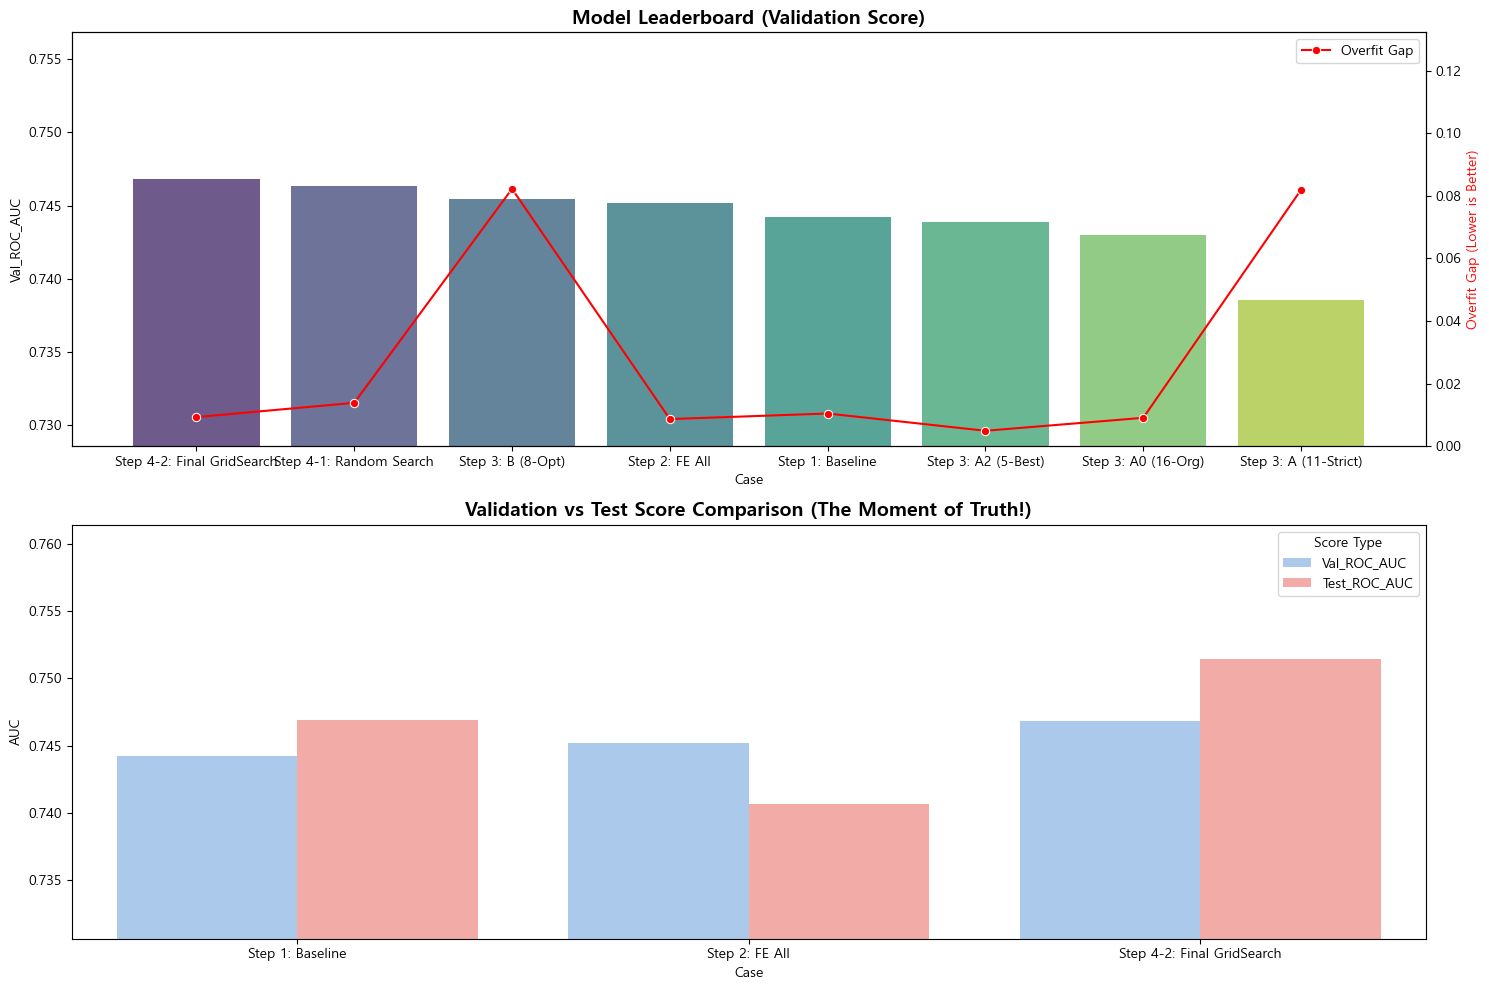

In [41]:
# 점수를 뽑아서 합치기
if 'df_test_final' in locals():
    score_dict = df_test_final.set_index('Case')['Test_ROC_AUC'].to_dict()
    print("실전 점수 추출 완료:", score_dict)
else:
    print("에러: df_test_final이 없습니다. Step 5-2를 먼저 실행해주세요!")
    score_dict = {}

model_performance_list = [] 
X_tuning = X_fe_all[cols_B]

full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B),]
if 'random_gb' in locals(): full_flow_list.append(("Step 4-1: Random Search", random_gb))
if 'grid_final' in locals(): full_flow_list.append(("Step 4-2: Final GridSearch", grid_final))

for case_name, res in full_flow_list:
    if hasattr(res, 'best_score_'): 
        best_obj = res.best_estimator_
        val_score = res.best_score_
        y_pred = best_obj.predict(X_tuning)
        y_proba = best_obj.predict_proba(X_tuning)[:, 1]
        
        acc = accuracy_score(y_tuning, y_pred)
        train_score = roc_auc_score(y_tuning, y_proba)
    else: 
        best_row = res.iloc[0]
        acc = best_row['Accuracy']
        val_score = best_row['Val_ROC_AUC']
        train_score = best_row['Train_ROC_AUC']

    model_performance_list.append({
        'Case': case_name,
        'Accuracy': acc,
        'Val_ROC_AUC': val_score,
        'Train_ROC_AUC': train_score,
        'AUC_Gap': train_score - val_score})

df_viz = pd.DataFrame(model_performance_list)

test_scores_map = {
    "Step 1: Baseline": score_dict.get("Step 1: Baseline"),
    "Step 2: FE All": score_dict.get("Step 2: FE All"),
    "Step 4-2: Final GridSearch": score_dict.get("Step 4: Champion") }

df_viz['Test_ROC_AUC'] = df_viz['Case'].map(test_scores_map)

df_viz['Test_ROC_AUC'] = df_viz['Test_ROC_AUC'].astype(float)

df_final_all = df_viz.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, 'Rank', range(1, len(df_final_all) + 1))

# 점수 출력
display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 
        'Train_ROC_AUC': '{:.4f}', 'Test_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'}))

# 점수 시각화
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
df_viz_sorted = df_viz.sort_values("Val_ROC_AUC", ascending=False)
ax1 = sns.barplot(x='Case', y='Val_ROC_AUC', data=df_viz_sorted, palette='viridis', alpha=0.8)

min_auc = df_viz_sorted['Val_ROC_AUC'].min() - 0.01
max_auc = df_viz_sorted['Val_ROC_AUC'].max() + 0.01
plt.ylim(min_auc, max_auc) 
plt.title('Model Leaderboard (Validation Score)', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='AUC_Gap', data=df_viz_sorted, marker='o', color='red', ax=ax2, label='Overfit Gap')
plt.ylim(0, df_viz_sorted['AUC_Gap'].max() + 0.05)
plt.ylabel('Overfit Gap (Lower is Better)', color='red')

plt.subplot(2, 1, 2)
df_test_exists = df_viz.dropna(subset=['Test_ROC_AUC']).copy() # NaN 제거

if len(df_test_exists) > 0:
    df_melt = df_test_exists.melt(id_vars=['Case'], value_vars=['Val_ROC_AUC', 'Test_ROC_AUC'], var_name='Type', value_name='AUC')
    
    sns.barplot(x='Case', y='AUC', hue='Type', data=df_melt, palette=['#a1c9f4', '#ff9f9b'])
    
    y_min = df_test_exists[['Val_ROC_AUC', 'Test_ROC_AUC']].min().min() - 0.01
    y_max = df_test_exists[['Val_ROC_AUC', 'Test_ROC_AUC']].max().max() + 0.01
    plt.ylim(y_min, y_max)
    
    plt.title('Validation vs Test Score Comparison (The Moment of Truth!)', fontsize=14, fontweight='bold')
    plt.legend(title='Score Type')
else:
    plt.text(0.5, 0.5, "No Test Scores Available", ha='center', va='center', fontsize=15)

plt.tight_layout()
plt.show()

nan 값이 있는 모델들은 중간 검증 과정이라 최종 평가가 안됐음

### AutoGluon

In [42]:
target = 'Reached.on.Time_Y.N'
selected_cols = optimal_8_features + [target]

test_data = test_fe[selected_cols]

hyperparameters = {
    'LR': {},   # Logistic Regression
    'RF': {},   # Random Forest
    'XT': {},   # Extra Trees
    'CAT': {},  # CatBoost
    'GBM': {}}   # LightGBM

print("[Medium]")
predictor_me = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols], 
    hyperparameters=hyperparameters,
    presets='medium_quality')

print("\n[Good]")
predictor_go = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='high_quality')

print("\n[Best]")
predictor_best = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='best_quality')

No path specified. Models will be saved in: "AutogluonModels\ag-20260212_084519"
Verbosity: 2 (Standard Logging)


[Medium]


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.7.1+cu118
CUDA Version:       11.8
GPU Memory:         GPU 0: 8.00/8.00 GB
Total GPU Memory:   Free: 8.00 GB, Allocated: 0.00 GB, Total: 8.00 GB
GPU Count:          1
Memory Avail:       13.43 GB / 31.87 GB (42.1%)
Disk Space Avail:   482.33 GB / 930.61 GB (51.8%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260212_084519"
Train Data Rows:    8799
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type


[Good]


Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260212_084530\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    13501.97 MB
	Train Data (Original)  Memory Usage: 0.48 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generat


[Best]


Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260212_084802\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    12481.95 MB
	Train Data (Original)  Memory Usage: 0.48 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generat

In [43]:
# AutoGluon으로 돌린 모델 중 뛰어난 모델 찾기
logging.getLogger("autogluon").setLevel(logging.ERROR)

LABEL = target if 'target' in globals() else TARGET

assert 'X_test_shared' in globals() and 'y_test_shared' in globals(), \
    "X_test_shared/y_test_shared가 없습니다. TEST_PAPER_BINDING 셀 먼저 실행하세요."

HOME = os.getcwd()
MODEL_DIR = os.path.join(HOME, "AutogluonModels")
print(f"HOME: {HOME}")
print(f"MODEL_DIR: {MODEL_DIR}")

pkl_list = glob.glob(os.path.join(MODEL_DIR, "**", "predictor.pkl"), recursive=True)
predictor_paths = sorted(set(os.path.dirname(p) for p in pkl_list))
print(f"발견된 predictor 수: {len(predictor_paths)}개")

FILTER_OLD = True
if FILTER_OLD:
    predictor_paths = [p for p in predictor_paths if "old" not in p.lower()]
    print(f"old 폴더 제외 후 predictor 수: {len(predictor_paths)}개")

def get_pos_proba(p, X):
    proba = p.predict_proba(X)
    if 1 in proba.columns:
        return proba[1].values  
    if "1" in proba.columns:
        return proba["1"].values
    return proba.iloc[:, -1].values

rows_ok, rows_skip = [], []

for path in predictor_paths:
    try:
        pred = TabularPredictor.load(path)

        _ = pred.predict_proba(X_test_shared.head(3))

        y_pred = get_pos_proba(pred, X_test_shared)
        auc = roc_auc_score(y_test_shared, y_pred)

        rows_ok.append({
            "roc_auc": float(auc),
            "path": path,})

    except Exception as e:
        rows_skip.append({"path": path, "reason": str(e)[:120]})

df_ok = pd.DataFrame(rows_ok).sort_values("roc_auc", ascending=False).reset_index(drop=True)
df_skip = pd.DataFrame(rows_skip)

print("\n(B케이스 기준) AutoGluon 채점 성공 TOP 10")
display(df_ok.head(10))

print(f"\n⏭스킵된 predictor 수: {len(df_skip)}개")
if len(df_skip) > 0:
    display(df_skip["reason"].value_counts().head(5))

if len(df_ok) > 0:
    ag_best_path = df_ok.loc[0, "path"]
    ag_best_auc  = df_ok.loc[0, "roc_auc"]
    ag_best_predictor = TabularPredictor.load(ag_best_path)
    print(f"\nBEST(B케이스): AUC={ag_best_auc:.6f}")
    print(f"PATH: {ag_best_path}")
else:
    print("\n(B케이스 기준) 채점 성공 predictor가 없습니다.")


HOME: c:\Users\lamph\github\E-commerce
MODEL_DIR: c:\Users\lamph\github\E-commerce\AutogluonModels
발견된 predictor 수: 6개
old 폴더 제외 후 predictor 수: 6개

(B케이스 기준) AutoGluon 채점 성공 TOP 10


,roc_auc,path
0,0.752618,c:\Users\lamph\github\E-commerce\AutogluonMode...
1,0.752618,c:\Users\lamph\github\E-commerce\AutogluonMode...
2,0.746056,c:\Users\lamph\github\E-commerce\AutogluonMode...
3,0.746056,c:\Users\lamph\github\E-commerce\AutogluonMode...
4,0.730752,c:\Users\lamph\github\E-commerce\AutogluonMode...
5,0.730752,c:\Users\lamph\github\E-commerce\AutogluonMode...



⏭스킵된 predictor 수: 0개

BEST(B케이스): AUC=0.752618
PATH: c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260212_045442


In [44]:
if 'predictor_best' in locals():
    # 리더보드에서 1등의 점수를 직접 추출
    best_val = predictor_best.leaderboard(test_data, silent=True)['score_test'].max()
    automl_scores = [{'Case': 'Step 5: AutoML(Best)', 'Test_ROC_AUC': best_val}]
else:
    automl_scores = []

In [45]:
# 수동모델, 자동모델 비교
manual_scores = []

name_mapping = {
    'Step 4: Champion': 'Step 4-2: Final GridSearch',
    'Step 2: FE All':   'Step 2: FE All',
    'Step 1: Baseline': 'Step 1: Baseline'}

if 'df_test_final' in locals():
    for _, row in df_test_final.iterrows():
        test_name = row['Case']
        score = row['Test_ROC_AUC']
        
        if test_name in name_mapping:
            final_name = name_mapping[test_name]
            manual_scores.append({'Case': final_name, 'Test_ROC_AUC': score})
            print(f"{final_name} 점수 연동 완료: {score:.4f}")
else:
    print("에러: 'df_test_final' 변수가 없습니다. Step 5-2(실전 채점)를 먼저 실행해주세요!")

if 'automl_scores' not in locals(): 
    print("경고: automl_scores가 없습니다. AutoML 단계가 실행되지 않았을 수 있습니다.")
    automl_scores = []

all_grand_scores = manual_scores + automl_scores

df_grand_final = pd.DataFrame(all_grand_scores).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)

df_grand_final.insert(0, 'Rank', range(1, len(df_grand_final) + 1))

display(df_grand_final.style
    .background_gradient(cmap='YlGnBu', subset=['Test_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Test_ROC_AUC'])
    .format({'Test_ROC_AUC': '{:.4f}'}))

Step 1: Baseline 점수 연동 완료: 0.7469
Step 2: FE All 점수 연동 완료: 0.7406
Step 4-2: Final GridSearch 점수 연동 완료: 0.7514


,Rank,Case,Test_ROC_AUC
0,1,Step 4-2: Final GridSearch,0.7514
1,2,Step 5: AutoML(Best),0.7507
2,3,Step 1: Baseline,0.7469
3,4,Step 2: FE All,0.7406


수동모델과 자동모델을 비교했을 때
GridSearchCV를 돌린 모델이 가장 성능이 좋게 나왔음

AutoML predictor: ag_best_predictor 사용
AutoML importance input: X_test_shared 사용
AutoML 중요도 계산 중... (잠시만 기다려주세요!)
AutoML 중요도 추출 완료!
수동 모델 중요도 추출 완료!


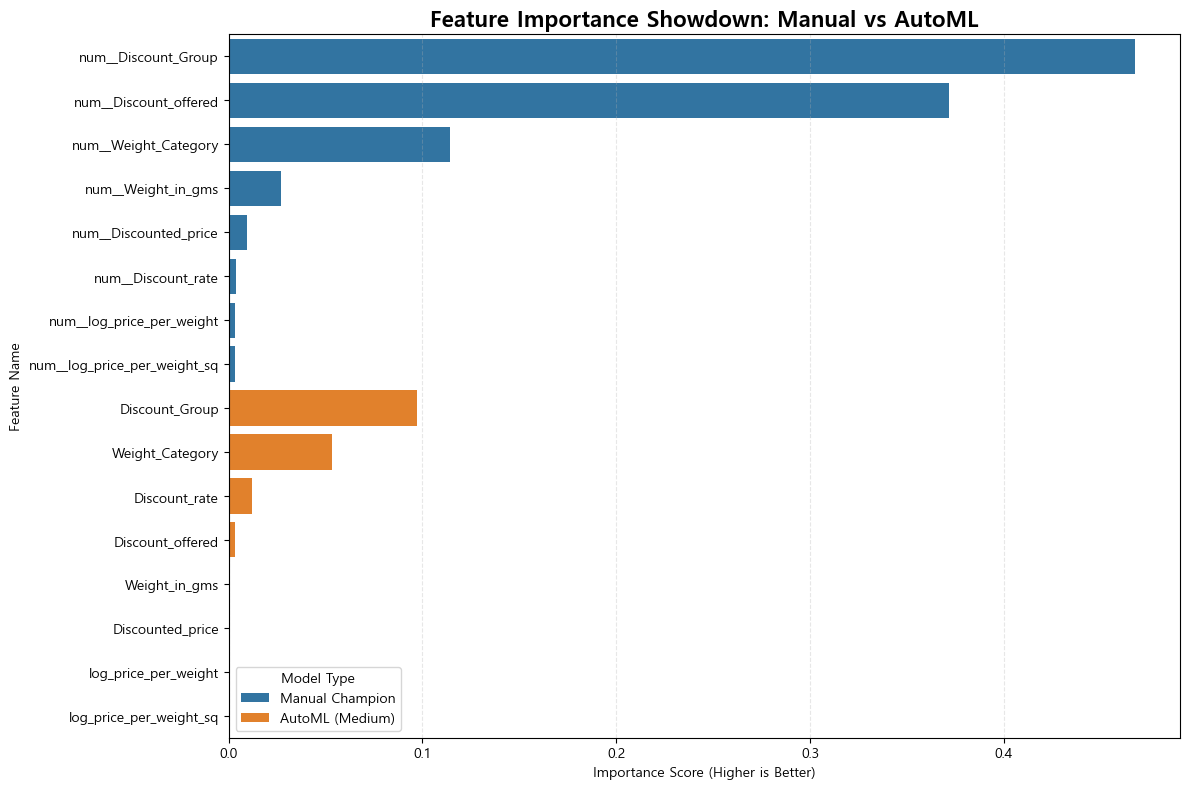


[Manual Top 5 Features]


,Feature,Importance
0,num__Discount_Group,0.467556
1,num__Discount_offered,0.371810
2,num__Weight_Category,0.114065
3,num__Weight_in_gms,0.027053
4,num__Discounted_price,0.009409



[AutoML Top 5 Features]


,Feature,Importance
0,Discount_Group,0.097249
1,Weight_Category,0.053499
2,Discount_rate,0.012102
3,Discount_offered,0.003281
4,Weight_in_gms,0.000000


In [46]:
LABEL = target if 'target' in globals() else TARGET

SELECT_AUTOML = "best_non_old"

HOME = os.getcwd()
MODEL_DIR = os.path.join(HOME, "AutogluonModels")

def load_latest_predictor(model_dir):
    pkl_list = glob.glob(os.path.join(model_dir, "**", "predictor.pkl"), recursive=True)
    if not pkl_list:
        raise FileNotFoundError("predictor.pkl을 찾지 못했습니다.")
    latest_pkl = max(pkl_list, key=os.path.getmtime)
    return TabularPredictor.load(os.path.dirname(latest_pkl))

try:
    if SELECT_AUTOML == "best_non_old" and 'ag_best_predictor' in globals():
        predictor = ag_best_predictor
        print("AutoML predictor: ag_best_predictor 사용")
    else:
        predictor = load_latest_predictor(MODEL_DIR)
        print("AutoML predictor: 최신 predictor 사용")
except Exception as e:
    print(f"AutoML predictor 로드 실패: {e}")
    predictor = None

try:
    if 'X_test_shared' in globals() and 'y_test_shared' in globals():
        X_for_automl = X_test_shared.copy()
        y_for_automl = y_test_shared.copy()
        print("AutoML importance input: X_test_shared 사용")
    else:
        X_for_automl = X_test_final.copy()
        y_for_automl = y_test_real
        print("AutoML importance input: X_test_final 사용")

    test_data_full = X_for_automl.copy()
    test_data_full[LABEL] = y_for_automl

    fi_automl = pd.DataFrame()

    if predictor is not None:
        print("AutoML 중요도 계산 중... (잠시만 기다려주세요!)")
        fi_automl = predictor.feature_importance(test_data_full, silent=True)

        fi_automl = fi_automl.reset_index().rename(columns={'index': 'Feature', 'importance': 'Importance'})
        fi_automl['Model'] = 'AutoML (Medium)'  # 라벨은 원래대로 유지
        print("AutoML 중요도 추출 완료!")

except Exception as e:
    print(f"AutoML 중요도 계산 실패: {e}")
    fi_automl = pd.DataFrame()


if 'grid_final' in locals():
    best_model = grid_final.best_estimator_  # 파이프라인
    clf = best_model.named_steps['clf']
    pre = best_model.named_steps['pre']

    importances = clf.feature_importances_

    try:
        feature_names = pre.get_feature_names_out()
    except:
        print("변수 이름 매칭 중... (fallback)")
        if 'FEATURES' in globals():   # TEST_PAPER_BINDING에서 FEATURES를 쓴 경우
            feature_names = FEATURES
        else:
            feature_names = cols_B

        if len(feature_names) != len(importances):
            print(f"길이 불일치: 변수 {len(feature_names)}개 vs 중요도 {len(importances)}개")
            importances = importances[:len(feature_names)]

    fi_manual = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances,
        'Model': 'Manual Champion'
    }).sort_values('Importance', ascending=False)

    print("수동 모델 중요도 추출 완료!")
else:
    print("grid_final 모델이 없습니다.")
    fi_manual = pd.DataFrame()

if not fi_automl.empty and not fi_manual.empty:
    top_n = 10
    fi_combined = pd.concat([fi_manual.head(top_n), fi_automl.head(top_n)])

    plt.figure(figsize=(12, 8))
    sns.barplot(data=fi_combined, x='Importance', y='Feature', hue='Model',
                palette=['#1f77b4', '#ff7f0e'])
    plt.title('Feature Importance Showdown: Manual vs AutoML', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score (Higher is Better)')
    plt.ylabel('Feature Name')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.legend(title='Model Type')
    plt.tight_layout()
    plt.show()

    print("\n[Manual Top 5 Features]")
    display(fi_manual.head(5)[['Feature', 'Importance']])

    print("\n[AutoML Top 5 Features]")
    display(fi_automl.head(5)[['Feature', 'Importance']])

else:
    print("중요도 데이터를 추출하지 못해 그래프를 그릴 수 없습니다.")

# 모델 평가

1) 최종 결정 모델 평가
2) 현재 모델 데이터로 만들 수 있는 서비스

실전 점수 추출 완료: {'Step 1: Baseline': 0.7469310021800897, 'Step 2: FE All': 0.740621278327642, 'Step 4: Champion': 0.7514289933893225}


,Rank,Case,Accuracy,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Test_ROC_AUC
0,1,Step 4-2: Final GridSearch,0.6894,0.7468,0.7561,0.0093,0.7514
1,2,Step 4-1: Random Search,0.6903,0.7463,0.7602,0.0139,nan
2,3,Step 3: B (8-Opt),0.6796,0.7455,0.8277,0.0822,nan
3,4,Step 2: FE All,0.6862,0.7452,0.7539,0.0087,0.7406
4,5,Step 1: Baseline,0.6803,0.7442,0.7547,0.0105,0.7469
5,6,Step 3: A2 (5-Best),0.6868,0.7439,0.7488,0.0049,nan
6,7,Step 3: A0 (16-Org),0.6867,0.7430,0.7521,0.0091,nan
7,8,Step 3: A (11-Strict),0.6729,0.7386,0.8205,0.0819,nan


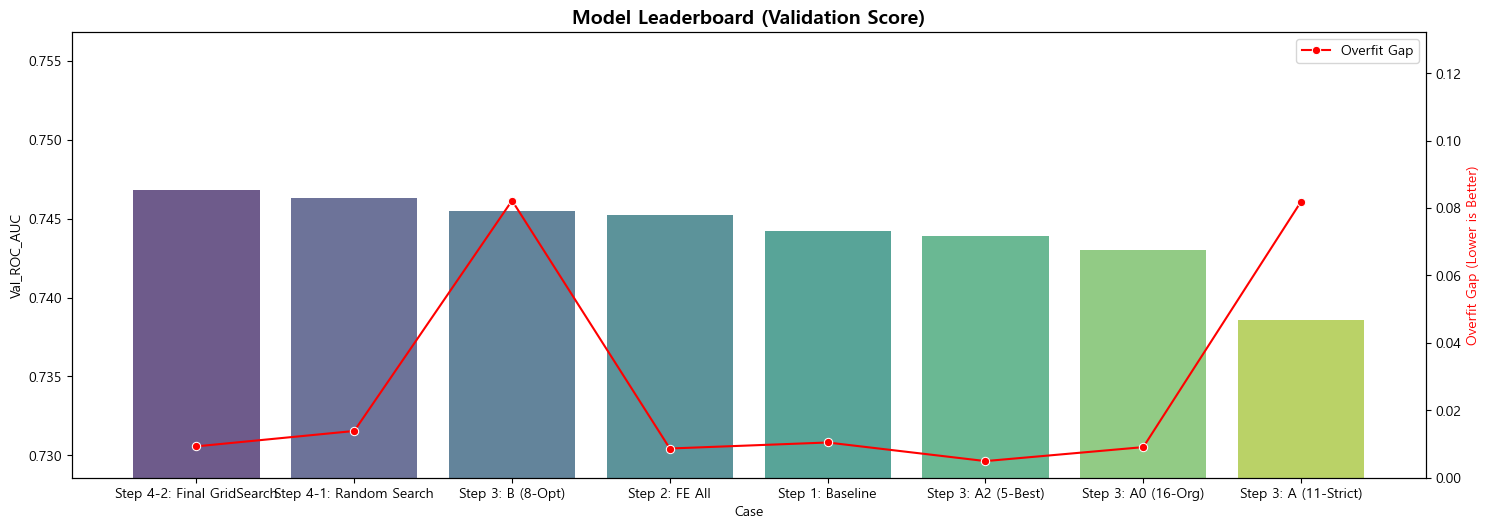

In [47]:
if 'df_test_final' in locals():
    score_dict = df_test_final.set_index('Case')['Test_ROC_AUC'].to_dict()
    print("실전 점수 추출 완료:", score_dict)
else:
    print("에러: df_test_final이 없습니다. Step 5-2를 먼저 실행해주세요!")
    score_dict = {}

model_performance_list = [] 
X_tuning = X_fe_all[cols_B]

full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B),]
if 'random_gb' in locals(): full_flow_list.append(("Step 4-1: Random Search", random_gb))
if 'grid_final' in locals(): full_flow_list.append(("Step 4-2: Final GridSearch", grid_final))

for case_name, res in full_flow_list:
    if hasattr(res, 'best_score_'): 
        best_obj = res.best_estimator_
        val_score = res.best_score_
        y_pred = best_obj.predict(X_tuning)
        y_proba = best_obj.predict_proba(X_tuning)[:, 1]
        
        acc = accuracy_score(y_tuning, y_pred)
        train_score = roc_auc_score(y_tuning, y_proba)
    else: 
        best_row = res.iloc[0]
        acc = best_row['Accuracy']
        val_score = best_row['Val_ROC_AUC']
        train_score = best_row['Train_ROC_AUC']

    model_performance_list.append({
        'Case': case_name,
        'Accuracy': acc,
        'Val_ROC_AUC': val_score,
        'Train_ROC_AUC': train_score,
        'AUC_Gap': train_score - val_score})

df_viz = pd.DataFrame(model_performance_list)

test_scores_map = {
    "Step 1: Baseline": score_dict.get("Step 1: Baseline"),
    "Step 2: FE All": score_dict.get("Step 2: FE All"),
    "Step 4-2: Final GridSearch": score_dict.get("Step 4: Champion") }

df_viz['Test_ROC_AUC'] = df_viz['Case'].map(test_scores_map)

df_viz['Test_ROC_AUC'] = df_viz['Test_ROC_AUC'].astype(float)

df_final_all = df_viz.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, 'Rank', range(1, len(df_final_all) + 1))

display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 
        'Train_ROC_AUC': '{:.4f}', 'Test_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'}))

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
df_viz_sorted = df_viz.sort_values("Val_ROC_AUC", ascending=False)
ax1 = sns.barplot(x='Case', y='Val_ROC_AUC', data=df_viz_sorted, palette='viridis', alpha=0.8)

min_auc = df_viz_sorted['Val_ROC_AUC'].min() - 0.01
max_auc = df_viz_sorted['Val_ROC_AUC'].max() + 0.01
plt.ylim(min_auc, max_auc) 
plt.title('Model Leaderboard (Validation Score)', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='AUC_Gap', data=df_viz_sorted, marker='o', color='red', ax=ax2, label='Overfit Gap')
plt.ylim(0, df_viz_sorted['AUC_Gap'].max() + 0.05)
plt.ylabel('Overfit Gap (Lower is Better)', color='red')

plt.tight_layout()
plt.show()

모델의 안정성을 평가하기 위해서 AUC_Gap의 값이 좋은 걸 찾았다.(낮은 값)

AUC_Gap이란, 검증데이터(Validation)와 실전데이터(Test)간의 성능 차이를 의미한다.
    Gap이 클수록 모델이 특정 데이터만을 가지고 판별할 수 있기 때문에 과적합을 찾아내기 위해 사용했다.

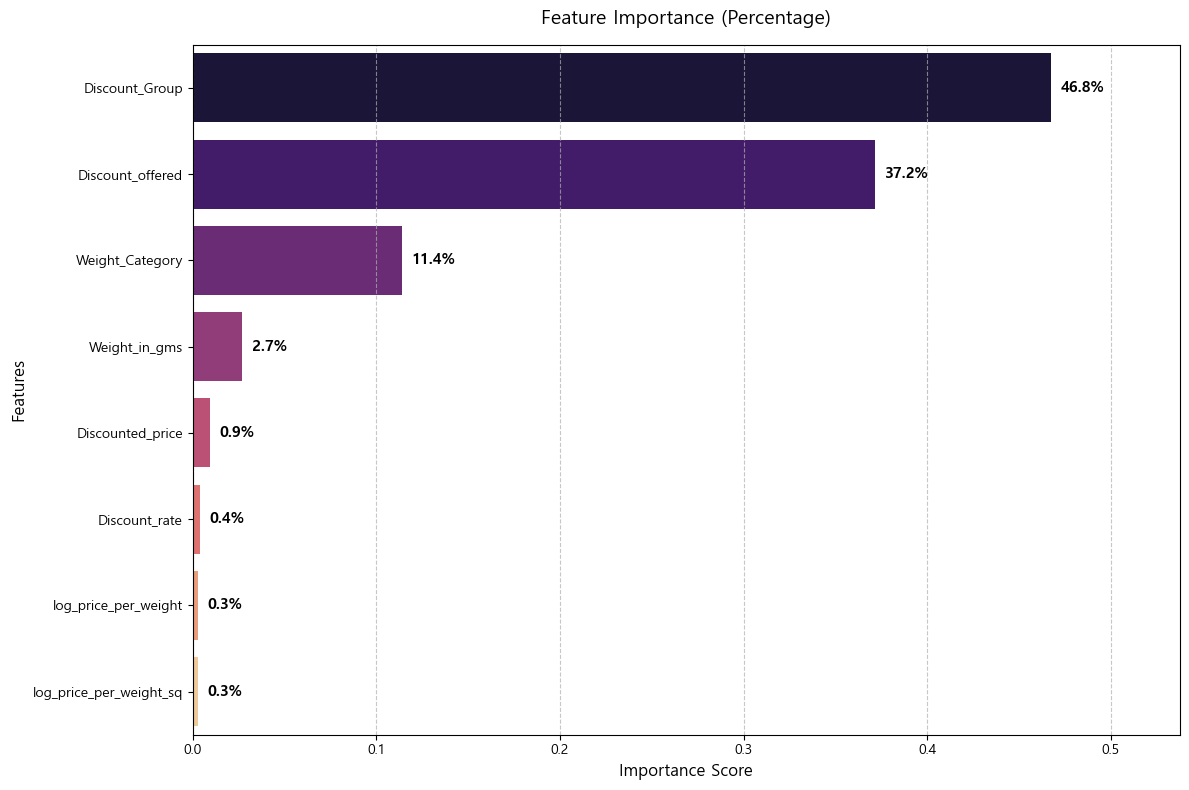

피처 중요도 상세 수치 (퍼센트 포함):
                   Feature  Importance  Percentage
0           Discount_Group    0.467556   46.755578
1         Discount_offered    0.371810   37.181024
2          Weight_Category    0.114065   11.406479
3            Weight_in_gms    0.027053    2.705318
4         Discounted_price    0.009409    0.940864
5            Discount_rate    0.003925    0.392457
6     log_price_per_weight    0.003162    0.316199
7  log_price_per_weight_sq    0.003021    0.302081


In [48]:
# 1. 파이프라인에서 실제 모델(Classifier) 부분 추출
final_clf = grid_final.best_estimator_.named_steps['clf']

# 2. 피처 중요도 값 가져오기
importances = final_clf.feature_importances_

# 3. 피처 이름 매칭 및 퍼센트 계산
feature_imp_df = pd.DataFrame({
    'Feature': cols_B,
    'Importance': importances
})

# 퍼센트 컬럼 추가 (전체 합 100 기준)
feature_imp_df['Percentage'] = (feature_imp_df['Importance'] / feature_imp_df['Importance'].sum()) * 100
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. 시각화
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='magma')

# 막대 옆에 퍼센트 숫자 표시
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2, 
             f'{width*100:.1f}%', 
             va='center', fontsize=11, fontweight='bold')

plt.title('Feature Importance (Percentage)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, feature_imp_df['Importance'].max() * 1.15) # 숫자 표시 공간 확보
plt.tight_layout()
plt.show()

# 5. 수치 데이터 출력 (보고서용)
print("피처 중요도 상세 수치 (퍼센트 포함):")
print(feature_imp_df[['Feature', 'Importance', 'Percentage']])

새로 만들어낸 파생변수가 유의미한 영향을 주는 것을 확인 할 수 있다

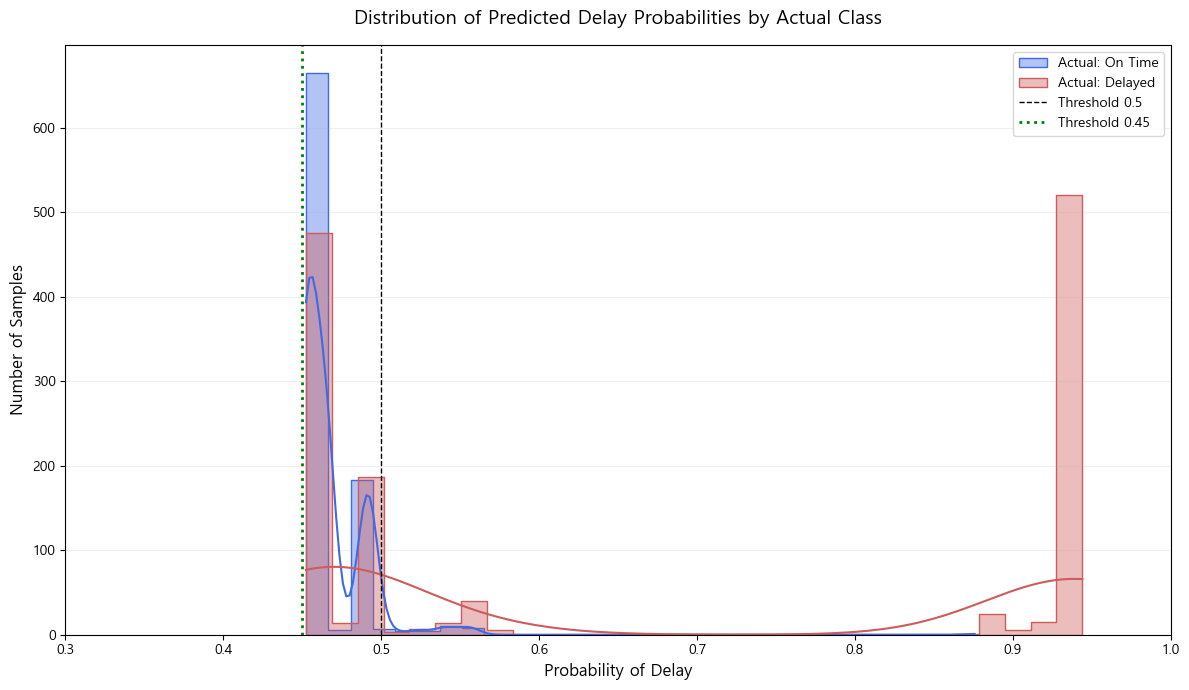

In [49]:
# 1. 테스트 데이터에 대한 예측 확률 추출
y_prob_final = grid_final.predict_proba(X_test_final)[:, 1]

# 2. 시각화 설정 (image_c35e18 스타일 반영)
plt.figure(figsize=(12, 7))

# 실제 정답에 따른 히스토그램 및 KDE 곡선
# On Time (정시) 분포
sns.histplot(y_prob_final[y_test_real == 0], bins=30, kde=True, 
             color='royalblue', label='Actual: On Time', alpha=0.4, element="step")

# Delayed (지연) 분포
sns.histplot(y_prob_final[y_test_real == 1], bins=30, kde=True, 
             color='indianred', label='Actual: Delayed', alpha=0.4, element="step")

# 3. 임계값 가이드라인 (기존 0.5 및 제안된 0.45)
plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
plt.axvline(0.45, color='green', linestyle=':', linewidth=2, label='Threshold 0.45')

# 4. 스타일링 및 라벨
plt.title('Distribution of Predicted Delay Probabilities by Actual Class', fontsize=14, pad=15)
plt.xlabel('Probability of Delay', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.xlim(0.3, 1.0) # image_c35e18의 데이터 범위를 반영

plt.tight_layout()
plt.show()

화물의 분포를 보여주는 그래프   

Actual On Time : 정시에 도착한 화물의 예측 분포 (0에 가까운 쪽에 있으면 좋은 모델)   
Actual:Delayed : 지연된 화물의 예측 분포 (1에 가까운 쪽에 있으면 좋은 모델)   
겹치는 부분 : 모델이 지연인지, 정시인지 헷갈려 하는 구간   
Threshold : 이 숫자보다 크면 지연이라고 판단함   

임계값(Threshold)를 낮추면 실제 지연 화물을 놓치지 않고 더 많이 포착할 수 있음을 확인, 이것은 실제로 모델을 운용 할 때 최적의 기준점을 찾는 근거가 될 수 있다.   

0.9에 '지연' 이 몰려있는 것을 볼 수 있는데, 이는 '지연'을 예측하는 모델의 신뢰성이 높다는 것을 보여준다.

# 서비스 기획
[기업의 운영 예산과 고객 만족도 사이에서 최적의 비용 효율 지점을 선택하도록 다양한 대안 제시]

운영 정책: 2-트랙 이중 임계값 전략

비용 구조와 운영 목적이 다른 두 가지 액션을 최적화하기 위해 고정된 하나의 지표가 아닌, 전략 A(내부 개입)와 전략 B(고객 대응)의 이중 임계값 체계를 설계했습니다.

1. 임계값 선정 원칙
- 리소스 최적화: 운영팀의 처리 한계(Capacity)를 고려하여 개입 물량 상한(cap)을 설정합니다.

- 효율적 구간 선택: 물량 증가 대비 재현율(Recall) 상승 폭이 둔화되는 지점(무릎점)을 선택하여 투입 비용 대비 효과를 극대화합니다.

- 가정치 적용: 현재 설정된 비율(29%, 40%)은 물량 규모에 따른 가변적 기준점입니다. 실제 운영 시에는 가용 리소스(인력, 예산 등)에 맞춰 이 관리 대상 범위를 자유롭게 조절 가능합니다.

| 구분 | 전략 A: 내부 선제 대응 (Internal) | 전략 B: 고객 리스크 완화 (External) |
|------|----------------------------------|------------------------------------|
| 관리 대상 | 지연확률 상위 29%  | 지연확률 상위 40%  |
| 임계값 (t) | 약 0.5417 | 약 0.4915 |
| 정밀도 (Precision) | 0.976 (판정 신뢰도 극대화) | 0.851 (준수한 예측 정확도) |
| 재현율 (Recall) | 0.470 (지연 건의 절반 수준 포착) | 0.570 (지연 건의 과반 이상 커버) |
| 주요 액션 | 우선 처리 플래그 및 운영팀 실시간 경고 | 알림톡 사전 고지 및 보상 쿠폰 준비 |
| 핵심 효과 | 지연 건수 자체를 감소시키는 선제 조치 | CS 부하 감소 및 고객 이탈 리스크 완화 |

In [50]:
y_score = grid_final.predict_proba(X_test_final)[:, 1]
y_true = y_test_shared.values
scores = y_score
n = len(scores)

def topk_policy(rate, name):
    k = int(np.ceil(rate * n))
    idx_sorted = np.argsort(scores)[::-1]
    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_sorted[:k]] = 1

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    realized = y_pred.mean()
    t_report = float(np.sort(scores)[::-1][k-1])

    print(f"[{name}] target_rate={rate:.2f} | realized_rate={realized:.3f} | t_report≈{t_report:.4f} | P={p:.3f} R={r:.3f} F1={f1:.3f}")
    return y_pred

y_internal = topk_policy(0.29, "전략 A: Internal Alert")
y_prealert = topk_policy(0.40, "전략 B: PreAlert SMS")

print("subset check (A ⊆ B):", np.all(y_internal <= y_prealert))

[전략 A: Internal Alert] target_rate=0.29 | realized_rate=0.290 | t_report≈0.5417 | P=0.976 R=0.474 F1=0.639
[전략 B: PreAlert SMS] target_rate=0.40 | realized_rate=0.400 | t_report≈0.4915 | P=0.851 R=0.570 F1=0.683
subset check (A ⊆ B): True


In [51]:
# 5%별로 어떤 값이 나올까 확인
y_true = y_test_shared.values
scores = y_score
n = len(scores)
idx_sorted = np.argsort(scores)[::-1]

rates = np.arange(0.05, 0.96, 0.05)
rows = []
for rate in rates:
    k = int(np.ceil(rate * n))
    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_sorted[:k]] = 1

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    rows.append({"rate": float(rate), "precision": float(p), "recall": float(r), "f1": float(f1)})

tbl = pd.DataFrame(rows)
tbl["delta_recall"] = tbl["recall"].diff()
tbl["delta_precision"] = tbl["precision"].diff()

display(tbl)

# 선택한 포인트 표시(29%, 40%는 근처 rate로)
print("\n참고: 선택한 포인트는 0.29 / 0.40 (Top-K) 위 표는 5% 단위 스윕이라 근처를 보면 됨")

,rate,precision,recall,f1,delta_recall,delta_precision
0,0.05,1.000000,0.083778,0.154603,NaN,NaN
1,0.10,1.000000,0.167555,0.287019,0.083778,0.000000
2,0.15,1.000000,0.252094,0.402676,0.084539,0.000000
3,0.20,1.000000,0.335110,0.501997,0.083016,0.000000
4,0.25,1.000000,0.418888,0.590446,0.083778,0.000000
5,0.30,0.959091,0.482102,0.641662,0.063214,-0.040909
6,0.35,0.894942,0.525514,0.662188,0.043412,-0.064149
7,0.40,0.851136,0.570449,0.683083,0.044935,-0.043805
8,0.45,0.808081,0.609292,0.694746,0.038842,-0.043056
9,0.50,0.772727,0.647372,0.704517,0.038081,-0.035354



참고: 선택한 포인트는 0.29 / 0.40 (Top-K) 위 표는 5% 단위 스윕이라 근처를 보면 됨


0.05 ~ 0.25구간 까지는 precision(지연을 맞출 확률)이 거의 100%이지만
0.29 ~ 0.40구간 까지는 확률이 줄어들다가 40이후부터 마이너스 폭이 커진다.

따라서 29% 와 40%를 임계점을 설정해볼 수 있다.

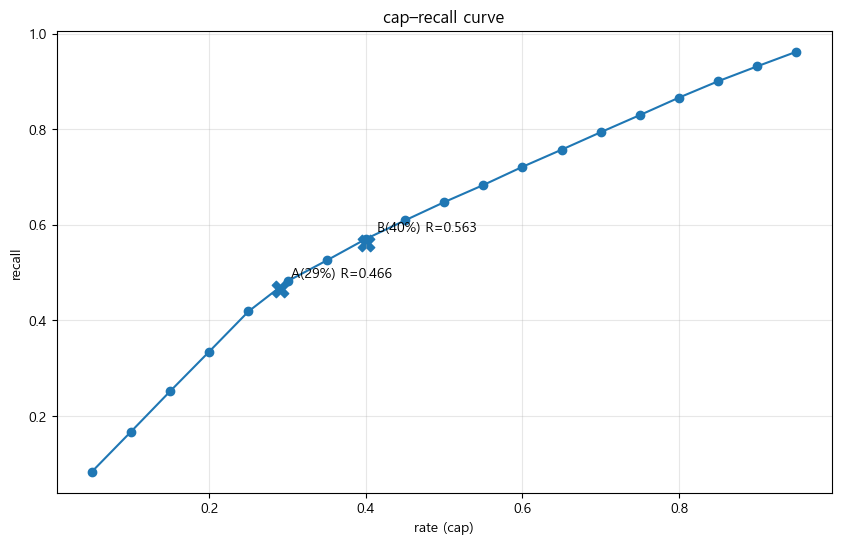

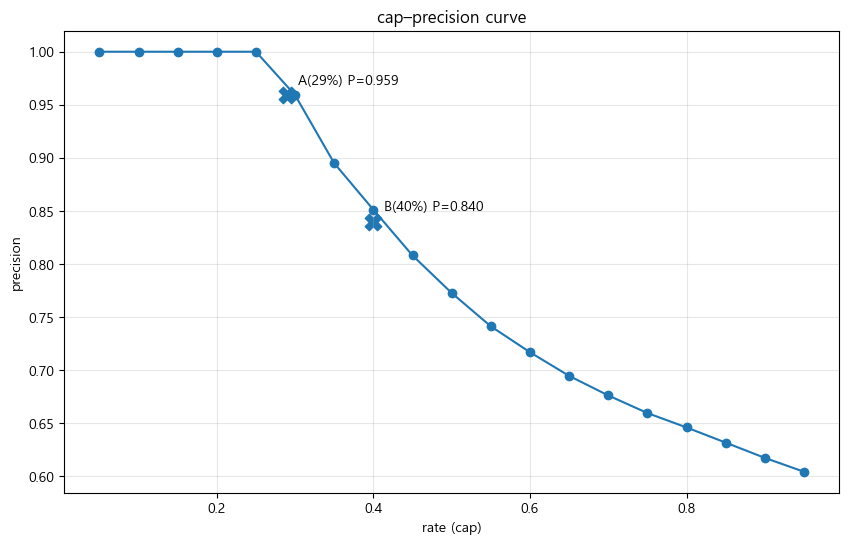

In [52]:
A_rate, A_recall, A_precision = 0.29, 0.466, 0.959
B_rate, B_recall, B_precision = 0.40, 0.563, 0.840

# (1) recall 그래프에 A/B 표시
plt.figure(figsize=(10,6))
plt.plot(tbl["rate"], tbl["recall"], marker="o")
plt.scatter([A_rate, B_rate], [A_recall, B_recall], s=140, marker="X")
plt.annotate(f"A(29%) R={A_recall:.3f}", (A_rate, A_recall), textcoords="offset points", xytext=(8,8))
plt.annotate(f"B(40%) R={B_recall:.3f}", (B_rate, B_recall), textcoords="offset points", xytext=(8,8))
plt.xlabel("rate (cap)")
plt.ylabel("recall")
plt.title("cap–recall curve")
plt.grid(True, alpha=0.3)
plt.show()

# (2) precision 그래프에 A/B 표시
plt.figure(figsize=(10,6))
plt.plot(tbl["rate"], tbl["precision"], marker="o")
plt.scatter([A_rate, B_rate], [A_precision, B_precision], s=140, marker="X")
plt.annotate(f"A(29%) P={A_precision:.3f}", (A_rate, A_precision), textcoords="offset points", xytext=(8,8))
plt.annotate(f"B(40%) P={B_precision:.3f}", (B_rate, B_precision), textcoords="offset points", xytext=(8,8))
plt.xlabel("rate (cap)")
plt.ylabel("precision")
plt.title("cap–precision curve")
plt.grid(True, alpha=0.3)
plt.show()

25%까지는 100%를 유지했고, 29%부터 줄어들기 시작하기 때문에
효율 면에서 뛰어난 서비스를 만들어 볼 수 있고,

40%부터 급격하게 마이너스 폭이 커지기 때문에
지연 예측이 신뢰도를 어느정도 지켜내면서 고객리스크를 최대한 관리하는 서비스를 만들어 볼 수 있다.